# 4 Feature Engineering

Transform the cleaned cohort into a model-ready feature matrix that captures the structural patterns surfaced by notebook 3's EDA. The output is `data/features.csv`, which notebook 5 splits, encodes, scales, and selects from before training begins, the final feature matrix for modeling.

**Why feature engineering earns its own notebook.** Cleaning (notebook 2) restores data integrity. EDA (notebook 3) surfaces the structural facts. Feature engineering (this notebook) translates those facts into representations the model can consume. Mixing the three steps inside a single notebook conflates *what the data says* with *how we encode it*, and makes the eventual feature matrix harder to audit.

**Section template.** Each subsection follows the framing then code then finding template introduced in notebook 2, so the Markdown alone yields a complete narrative of every engineered feature and its justification chain back to the EDA.


In [1]:
# Each downstream notebook depends on artefacts written by the prior stage.
# A fresh clone with an empty data/ directory will fail mid-cell otherwise.
# Run 'python run_pipeline.py' from the repo root to materialise the whole
# chain, or execute the upstream notebook(s) first.
import os

_required = ["../data/cleaned.csv"]
_missing = [p for p in _required if not os.path.exists(p)]
if _missing:
    raise FileNotFoundError(
        "Upstream artefact(s) missing: "
        + ", ".join(_missing)
        + ". Run the prior notebook or `python run_pipeline.py` from the repo root."
    )


## 4.1 Purpose and Scope

**What this notebook covers.** Target encoding (§4.2), age-bracket-to-numeric conversion (§4.3), frequency-based ICD-9 prefix grouping (§4.4), informative-missingness encoding for the lab columns (§4.5), top-K rollups for medical specialty (§4.6) and payer code (§4.7), administrative-code mapping (§4.8), medication features (§4.9), log-transforms on heavy-tailed prior-utilization counts (§4.10), derived service-utilization index (§4.11), the binary `change` flag (§4.12), patient-ID extraction (§4.13), interaction and ratio features (§4.14), a final-validation pass (§4.15), redundant-column drops (§4.16), and persistence with publish (§4.17). Section 4.18 summarizes every action.

**What this notebook does not cover.** No splitting, no scaling, no feature selection. Those happen in notebook 5 after the engineered frame is persisted. Patient-history aggregates are *deferred* to notebook 5 as well, because they must be computed on the training partition only to avoid leakage.

**Methodological note on dual representations.** Several columns are persisted in *both* raw and engineered form (for example `number_inpatient` alongside its `_log1p` variant, or `age` alongside `age_mid`). This is deliberate: tree models and linear models prefer different representations, and notebook 5's mutual-information selection picks whichever variant best separates the target. The cost of pre-emptively dropping one representation would be silently losing whichever the model would have preferred.


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "pipeline":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Double-check dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

df = pd.read_csv("../data/cleaned.csv")
print(f"Input shape: {df.shape}")
df.head(3)

Input shape: (99340, 56)


,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,glimepiride,...,readmitted,weight_recorded,race_missing,payer_code_missing,medical_specialty_missing,A1C_measured,glu_measured,readmitted_canonical,age_mid,diag_1_cat,diag_2_cat,diag_3_cat,medical_specialty_grouped,log_number_outpatient,has_any_number_outpatient,log_number_emergency,has_any_number_emergency,log_number_inpatient,has_any_number_inpatient,metformin_taking,glipizide_taking,glyburide_taking,insulin_taking,num_medications_log1p,num_procedures_log1p
0,8222157,Caucasian,Female,[0-10),NaN,NaN,1.0,1,Unknown,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,Unknown,Unknown,1,not_measured,not_measured,No,No,No,...,NO,0,0,1,0,0,0,no,5,250,Unknown,Unknown,Other,0.000000,0,0.0,0,0.000000,0,0,0,0,0,0.693147,0.000000
1,55629189,Caucasian,Female,[10-20),1.0,1.0,7.0,3,Unknown,Unknown,59,0,18,0,0,0,276,250.01,255,9,not_measured,not_measured,No,No,No,...,>30,0,0,1,1,0,0,gt30,15,276,250,Other,Unknown,0.000000,0,0.0,0,0.000000,0,0,0,0,1,2.944439,0.000000
2,86047875,AfricanAmerican,Female,[20-30),1.0,1.0,7.0,2,Unknown,Unknown,11,5,13,2,0,1,648,250,V27,6,not_measured,not_measured,No,No,No,...,NO,0,0,1,1,0,0,no,25,Other,250,Unknown,Unknown,1.098612,1,0.0,0,0.693147,1,0,1,0,0,2.639057,1.791759


In [3]:
# Helper: plot readmission rates by a categorical feature
def plot_readmission_rate(data, _col, _ax=None, title=None):
    """Stacked bar of readmission % by a categorical column."""
    ct = pd.crosstab(data[_col], data["readmitted"], normalize="index") * 100
    ct = ct.reindex(columns=["NO", ">30", "<30"], fill_value=0)
    ct.plot.bar(stacked=True, ax=_ax, colormap="Set2", edgecolor="white", width=0.8)
    if _ax:
        _ax.set_title(title or _col)
        _ax.set_ylabel("%")
        _ax.legend(title="Readme.", fontsize=8, loc="upper right")
    return ct

### 4.1.1 Helper and Data Load

**What just executed.** The cleaned cohort is loaded, and a small `plot_readmission_rate(...)` helper is defined for the validation charts that recur throughout the notebook. Each subsequent section uses this helper to confirm that the engineered feature actually stratifies the target.

**Why a single shared helper instead of ad-hoc plots.** Twelve of the sections below produce essentially the same chart (engineered feature on the x-axis, readmission rate on the y-axis). Defining one helper keeps every chart consistent in style and ensures any visual update affects all sections simultaneously.


## 4.2 Target Encoding: Three Classes to Binary

**What we are doing.** Creating `readmitted_binary` (1 if `<30`, else 0) alongside the original three-class label.

**Why retain the three-class label.** The binary target is what the model is trained on, but the three-class label remains useful for stratification (notebook 5's split uses `<30` as the positive class) and for any downstream analysis that wants to distinguish `>30` readmissions from non-readmissions. Keeping both adds one column at a negligible cost.

**Why the `<30`-day window.** The `<30`-day window aligns with the CMS Hospital Readmissions Reduction Program metric, which is also why the dataset distinguishes `<30` from `>=30`. Predicting all readmissions or a 90-day window are valid alternative targets and would require relabelling but no other pipeline change.



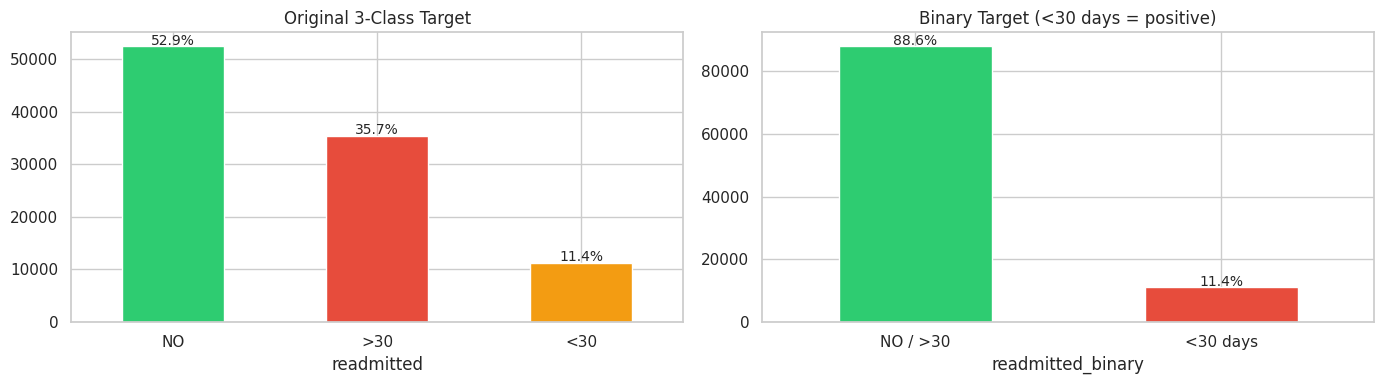

Positive rate (binary): 11.4%


In [4]:
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 3-class
vc3 = df["readmitted"].value_counts()
vc3.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c", "#f39c12"], edgecolor="white")
axes[0].set_title("Original 3-Class Target")
axes[0].tick_params(axis="x", rotation=0)
for i, (val, cnt) in enumerate(vc3.items()):
    axes[0].text(i, cnt + 300, f"{cnt / len(df) * 100:.1f}%", ha="center", fontsize=10)

# Binary
vc2 = df["readmitted_binary"].value_counts().rename({0: "NO / >30", 1: "<30 days"})
vc2.plot.bar(ax=axes[1], color=["#2ecc71", "#e74c3c"], edgecolor="white")
axes[1].set_title("Binary Target (<30 days = positive)")
axes[1].tick_params(axis="x", rotation=0)
for i, (val, cnt) in enumerate(vc2.items()):
    axes[1].text(i, cnt + 300, f"{cnt / len(df) * 100:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()
print(f"Positive rate (binary): {df['readmitted_binary'].mean() * 100:.1f}%")

**Validation.** The binary target sits at roughly 11% positive rate, the same prevalence observed in notebook 3's EDA. The bar chart confirms the encoding round-trips correctly: every `<30` row maps to 1 and every other row maps to 0.


## 4.3 Age: Bracket to Numeric Midpoint

**What we are doing.** Mapping string brackets like `[70-80)` to numeric midpoints like `75`. The original bracket label is preserved for any downstream model that prefers categorical age.

**Why midpoints rather than ordinal codes.** An ordinal encoding (`[0-10)=0, [10-20)=1, ...`) preserves the order but loses the physical interpretation, because the integer index no longer reads as age-in-years. The midpoint encoding (`[70-80)=75`) gives the model an explicit age-in-years variable, which is what we want for coefficient interpretation and SHAP-value readability. Both encodings step in 10-year intervals, so the spacing is identical, only the units differ.

**Why we keep the bracket too.** Tree models can split on either representation. Keeping both lets the notebook-5 mutual-information selection pick the representation that best stratifies the target.

**Protected-attribute note.** Age is a protected attribute under US ADEA and EU anti-discrimination frameworks for adjacent employment and lending decisions. The encoding choice here is justified for predictive quality, but downstream subgroup evaluation should compare champion recall and FPR across at least three age bands (under 50, 50 to 69, 70+), so the choice carries an explicit deployment-time check.



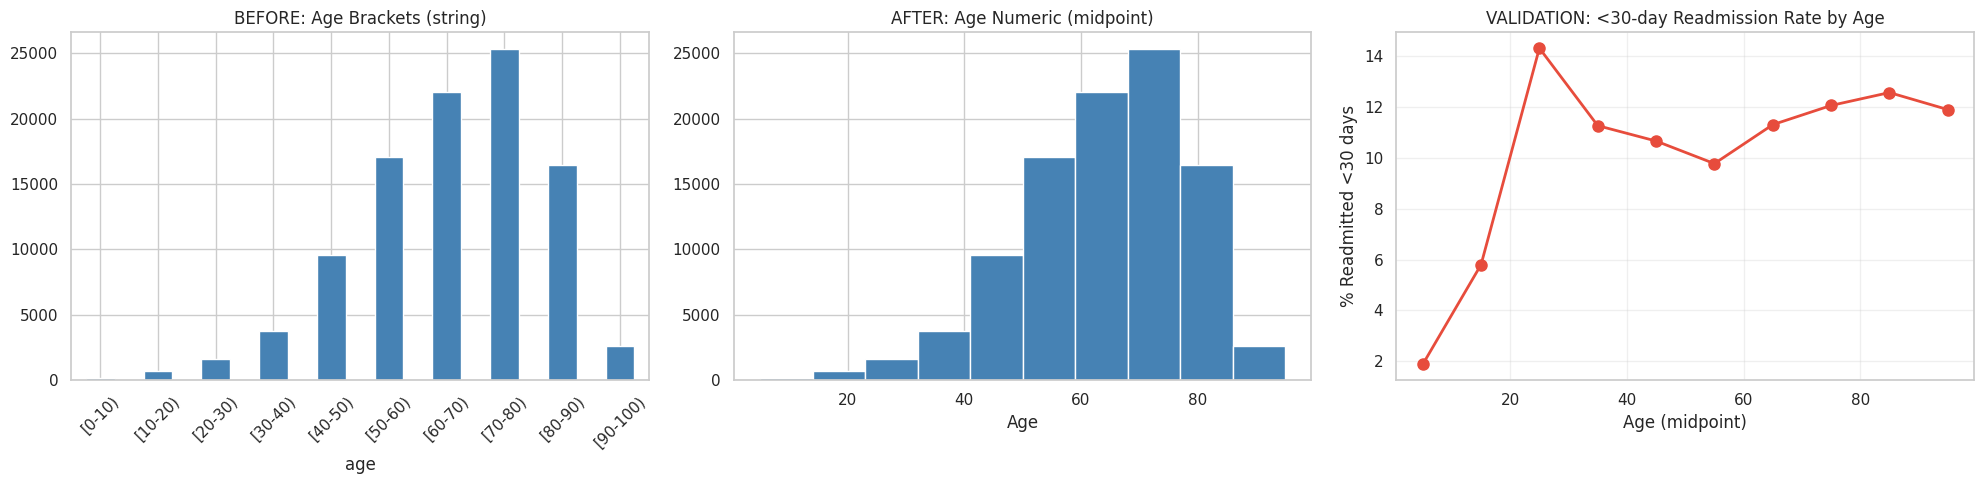

In [5]:
age_map = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35, "[40-50)": 45,
    "[50-60)": 55, "[60-70)": 65, "[70-80)": 75, "[80-90)": 85, "[90-100)": 95,
}
df["age_numeric"] = df["age"].map(age_map)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Before: bracket counts
df["age"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("BEFORE: Age Brackets (string)")
axes[0].tick_params(axis="x", rotation=45)

# After: numeric histogram
df["age_numeric"].hist(bins=10, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("AFTER: Age Numeric (midpoint)")
axes[1].set_xlabel("Age")

# Proof: age vs readmission rate
age_readm = df.groupby("age_numeric")["readmitted_binary"].mean() * 100
axes[2].plot(age_readm.index, age_readm.values, "o-", color="#e74c3c", linewidth=2, markersize=8)
axes[2].set_title("VALIDATION: <30-day Readmission Rate by Age")
axes[2].set_xlabel("Age (midpoint)")
axes[2].set_ylabel("% Readmitted <30 days")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

df = df.drop(columns=["age"])


**Validation.** Readmission rate rises monotonically with age up to roughly 65, then plateaus through the highest brackets. The numeric midpoint encoding will let linear models capture the lower portion of this curve, and tree models will capture the plateau through their natural splitting behaviour.

**Fairness forward reference.** `age_mid` is a protected-attribute feature on the fairness allowlist (`helpers/fairness.PROTECTED_ATTRIBUTE_COLUMNS`). The §8 model card reports recall and FPR per original 10-year bracket so the encoding choice does not hide subgroup behaviour.

## 4.4 Diagnosis Codes: Frequency-Based ICD-9 Prefix Grouping

**What we are doing.** Mapping each of the three ICD-9 diagnosis columns (roughly 700 unique codes each) to a smaller set of category labels. The mapper here is *frequency-based*: it surfaces the top-K most common 3-digit ICD-9 prefixes in the training cohort and lumps the long tail into `"Other"`.

**Why frequency-based rather than chapter-based.** Notebook 3's EDA chapter rollup (Diabetes, Circulatory, Respiratory) is human-readable but coarse. A chapter contains dozens of distinct conditions with different readmission risk profiles. The frequency-based mapper preserves finer-grained signal by keeping individual prevalent codes (250 for diabetes, 428 for heart failure) as their own categories while collapsing the long tail. The two mappers can disagree on labels for the same encounter, which is expected and acceptable.

**Why this rollup must be train-only.** The choice of "which codes are common enough to keep" is a frequency threshold computed on training rows. Computing it on the full cohort would leak validation and test information into the encoding. The `build_train_mask_for_rollups` helper from notebook 2 enforces the train-only constraint.


In [6]:
# Add at top of NB04 §4.4
from helpers.clean_helpers import build_train_mask_for_rollup

_train_mask = build_train_mask_for_rollup(df, seed=42)
_train = df.loc[_train_mask]

# Re-derive the data-driven ICD-9 category mapper for Section 4
# (section reloads cleaned.csv, so we recompute rather than relying on state).
# Implementation note: this mapper does NOT apply a clinical taxonomy. It zero-pads
# each ICD-9 code to a 3-digit string prefix (V/E codes get bucketed as 'V-codes' /
# 'E-codes', blanks become 'Unknown'). The loop below keeps the top-N prefixes by
# frequency and folds the rest into 'Other'. The §4.4 Markdown describes the same.
from helpers.feature_eng import map_icd9

for col in ["diag_1", "diag_2", "diag_3"]:
    df[f"{col}_cat"] = df[col].apply(map_icd9)

_all_cats = pd.concat([_train[c] for c in ["diag_1_cat", "diag_2_cat", "diag_3_cat"]])
top_diag_cats = set(_all_cats.value_counts().head(15).index) | {"Unknown"}
for col in ["diag_1_cat", "diag_2_cat", "diag_3_cat"]:
    df[col] = df[col].where(df[col].isin(top_diag_cats), "Other")

print(f"diag_1: {df['diag_1'].nunique()} raw codes -> {df['diag_1_cat'].nunique()} categories")


diag_1: 716 raw codes -> 15 categories


### 4.4.1 Cardinality reduction: 716 raw codes to 17 categories

**What this chart shows.** Two side-by-side bar charts of `diag_1`, the primary diagnosis code on each encounter. The left panel shows the column before the mapper runs. The right panel shows it after.

- **BEFORE** is a histogram of the top 15 raw ICD-9 codes by frequency. The chart title also reports the total unique-code count, which exceeds 700 in the cleaned cohort. Even with the long tail truncated to the top 15, the rare codes dominate row volume. A model asked to learn one weight per raw code would fit noise more than signal.
- **AFTER** is the same histogram but on `diag_1_cat`, the column the §4.4 mapper produced in cell 12. Every 3-digit ICD-9 prefix that survived the top-K cut keeps its own bar. Everything else folds into `Other`. The bar count drops from the 700+ raw codes to the 17 bucketed categories printed by cell 12. That is the cardinality reduction the mapper provides.

**Why this matters.** The goal of §4.4 is to shrink the feature space without shrinking the prevalent signal. The BEFORE/AFTER comparison is the first half of the proof: cardinality fell, and prevalent prefixes (`250` diabetes, `428` heart failure, `414` ischemic heart disease) still appear as their own bars in the AFTER panel rather than being swept into `Other`. Subsection 4.4.2 then checks the second half: the surviving categories carry differential readmission risk.

**Threshold rule.** The mapper keeps the 15 most-frequent 3-digit ICD-9 prefixes pooled across `diag_1`, `diag_2`, and `diag_3` plus the `Unknown` bucket, and folds the long tail into `Other`. The 15 kept prefixes plus `Unknown` plus `Other` is the 17 categories the title reports. The kept prefixes individually each cover at least roughly 1% of diagnosis-slot rows, and together they cover the large majority of non-`Unknown` rows.


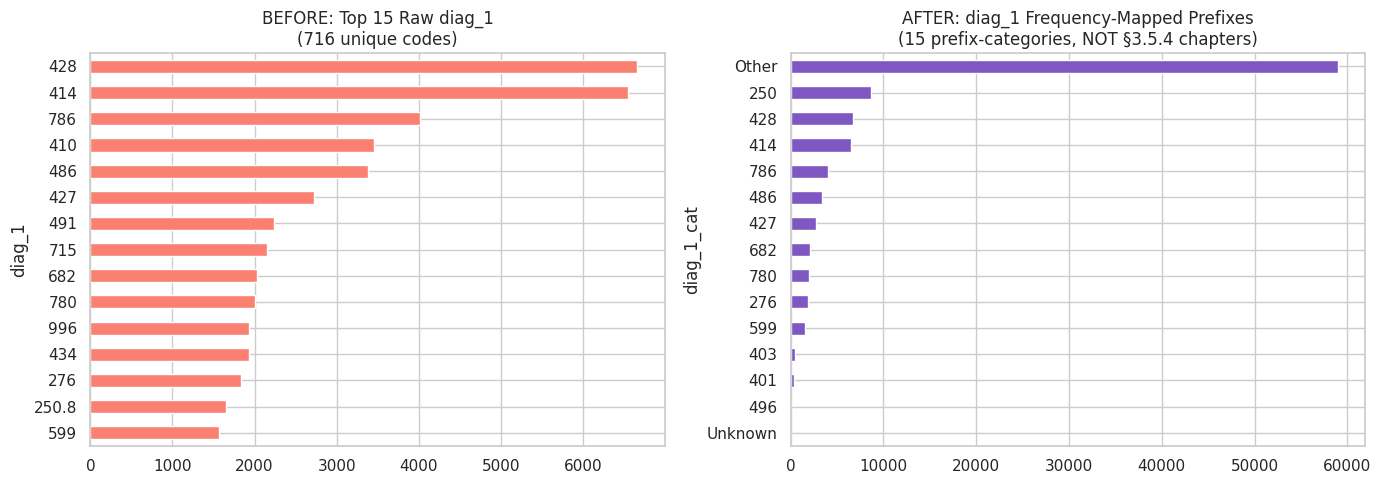

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BEFORE: raw code cardinality (top 15 of roughly 700 distinct codes)
df["diag_1"].value_counts().head(15).plot.barh(
    ax=axes[0], color="salmon", edgecolor="white",
)
axes[0].set_title(
    f"BEFORE: Top 15 Raw diag_1\n({df['diag_1'].nunique()} unique codes)",
)
axes[0].invert_yaxis()

# AFTER: frequency-mapped prefix categories (every surviving bucket fits on screen)
df["diag_1_cat"].value_counts().plot.barh(
    ax=axes[1], color="#7e57c2", edgecolor="white",
)
axes[1].set_title(
    f"AFTER: diag_1 Frequency-Mapped Prefixes\n"
    f"({df['diag_1_cat'].nunique()} prefix-categories, NOT §3.5.4 chapters)",
)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### 4.4.2 Validation: does the grouping retain readmission signal?

**What this chart shows.** A horizontal bar chart in which each bar gives the `<30`-day readmission rate for one primary-diagnosis category (`diag_1_cat`), with a dashed reference line at the cohort-wide average. Bars to the right of that line mark diagnoses whose readmission risk exceeds the cohort average. Bars to the left mark diagnoses whose risk is below it.

**Reading the result.** As clinical priors predict, `250` (diabetes) and `428` (heart failure) carry above-average `<30`-day readmission rates, while injury and musculoskeletal prefixes (`710` through `739`) sit below the average. The bars carry numeric prefixes rather than chapter names because the mapper here is frequency-based, not taxonomy-based. The taxonomy-based chapter rollup in EDA §3.5.4 (Diabetes, Circulatory, Respiratory) exists for human reading of the EDA breakdowns. The §4.4 mapper is what the model consumes. The two schemes can disagree on the labels assigned to a given encounter even though they describe the same patients.

**Why this matters.** The cardinality reduction in §4.4.1 is justified only when the surviving categories still carry differential outcome signal. The spread across this chart, from subaverage injury prefixes to well-above-average diabetes and heart failure, is that signal. A flat bar chart at this point would be a red flag: it would mean the top-K cut was too aggressive and collapsed the discriminative structure into `Other`. The cell also drops the raw `diag_1`, `diag_2`, and `diag_3` columns now that the `_cat` columns are the canonical feature.

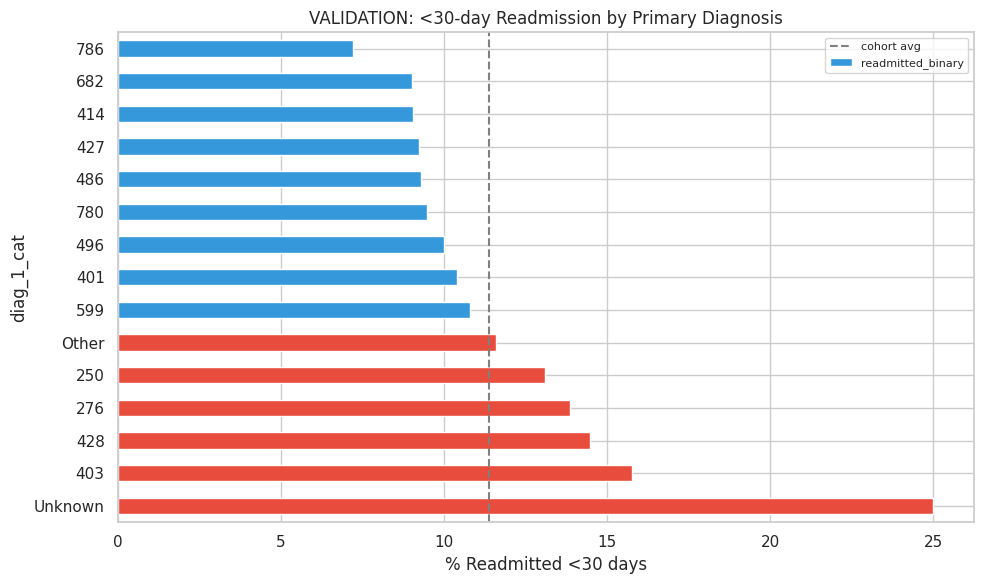

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

diag_readm = (
        df.groupby("diag_1_cat")["readmitted_binary"].mean()
        .sort_values(ascending=True) * 100
)
overall_rate = df["readmitted_binary"].mean() * 100
# Conditional colouring: red bars sit above the cohort average, blue bars
# below. The dashed reference line carries the same signal as a redundant cue.
bar_colors = ["#e74c3c" if v > overall_rate else "#3498db" for v in diag_readm.values]
diag_readm.plot.barh(ax=ax, color=bar_colors, edgecolor="white")

ax.set_title("VALIDATION: <30-day Readmission by Primary Diagnosis")
ax.set_xlabel("% Readmitted <30 days")
ax.invert_yaxis()
ax.axvline(
    overall_rate,
    color="gray", ls="--", label="cohort avg",
)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# The raw diag_{1,2,3} columns have served their purpose. The _cat columns
# are the canonical feature from here on.
df = df.drop(columns=["diag_1", "diag_2", "diag_3"])


## 4.5 Lab Results: Encode Missingness as a Feature

**What we are doing.** Splitting each lab column into a binary "was tested" flag and a categorical result that includes `"not_measured"` as an explicit level.

**Why this encoding is the right response to informative missingness.** Notebook 3 §3.6.4 showed that the *testing decision* carries signal (clinicians who suspect poor control order the test) while the *result*, on its own, is a weak predictor. The binary flag captures the decision. The categorical with `"not_measured"` captures the result and preserves the missingness as its own category for tree-model splits.

**Why we do not impute a result.** Imputing a glucose value for a patient who was never tested would fabricate clinical data. The notebook 2 §2.10 pipeline already replaced raw NaN with the sentinel `"not_measured"`, so `notna()` here would lie if used to derive the test-ordered flag. The cell below derives the flag from the sentinel value instead.


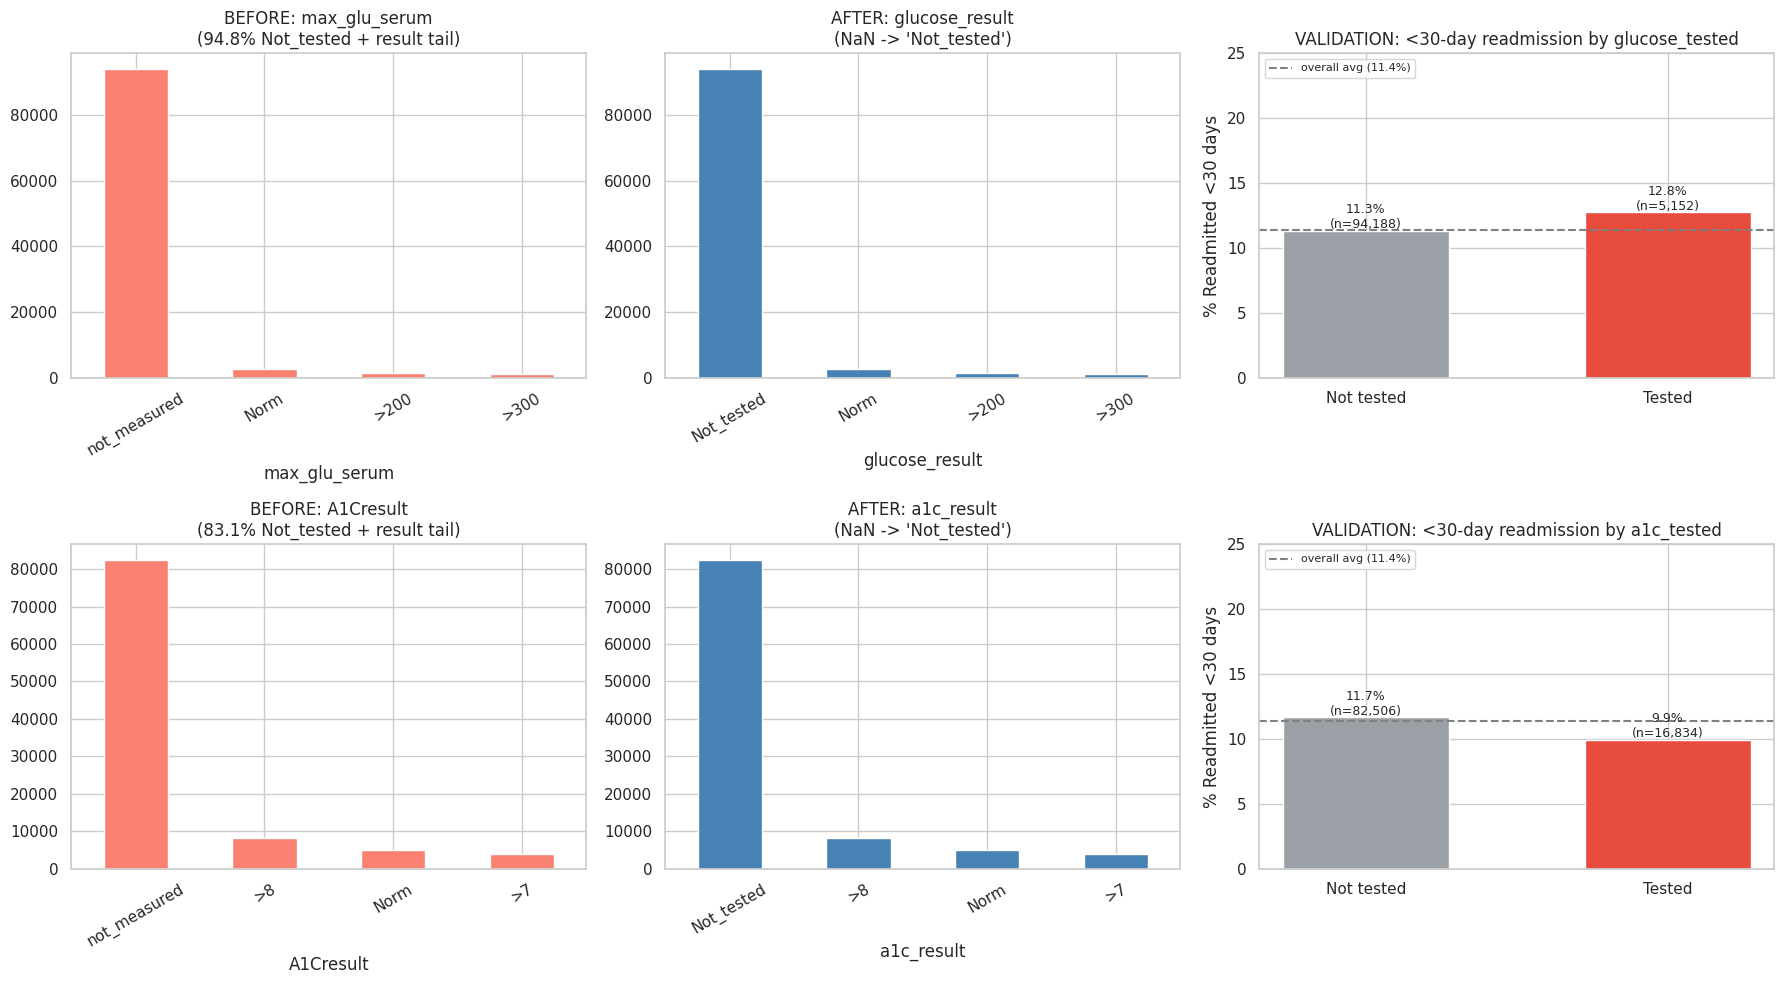

In [9]:
# Sentinel-aware lab-tested flags:
# §2.8 already replaced raw NaN with the sentinel "not_measured", so
# df[col].notna() is True for every row, and the '_tested' flag collapses to
# constant 1: the VALIDATION panel below would render a single bar and the
# chart cannot show the tested-vs.-untested comparison the prose advertises.
# Recover the tested-vs-untested split by checking the known untested
# sentinels instead. "Not_tested" appears later in this same cell as the
# AFTER-view sentinel. "None" is the raw Kaggle string for absent A1C/glucose
# results. "?" is the raw NA marker, kept here for symmetry across reruns.
_UNTESTED_SENTINELS = {"not_measured", "Not_tested", "None", "?"}
for col, prefix in [("max_glu_serum", "glucose"), ("A1Cresult", "a1c")]:
    df[f"{prefix}_tested"] = (~df[col].isin(_UNTESTED_SENTINELS)).astype(int)
    df[f"{prefix}_result"] = df[col].replace(list(_UNTESTED_SENTINELS), "Not_tested")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
_overall = df["readmitted_binary"].mean() * 100

for row, (col, prefix) in enumerate([("max_glu_serum", "glucose"), ("A1Cresult", "a1c")]):
    # BEFORE: actual raw distribution INCLUDING the NaN bucket, fillna('Not_tested') first so
    # the chart shows the ~94% Not_tested mass alongside the long-tail Norm/>200/>300 bars,
    # rather than collapsing to a 2-bar Available/Missing split.
    raw_view = df[col].fillna("Not_tested").value_counts()
    raw_view.plot.bar(ax=axes[row, 0], color="salmon", edgecolor="white")
    _missing_share = (1 - df[f"{prefix}_tested"]).mean() * 100
    axes[row, 0].set_title(f"BEFORE: {col}\n({_missing_share:.1f}% Not_tested + result tail)")
    axes[row, 0].tick_params(axis="x", rotation=30)

    # AFTER: result distribution including Not_tested (kept).
    df[f"{prefix}_result"].value_counts().plot.bar(ax=axes[row, 1], color="steelblue", edgecolor="white")
    axes[row, 1].set_title(f"AFTER: {prefix}_result\n(NaN -> 'Not_tested')")
    axes[row, 1].tick_params(axis="x", rotation=30)

    # VALIDATION: explicit 2-bar Not tested / Tested with the overall-avg reference line.
    readm_by_tested = df.groupby(f"{prefix}_tested")["readmitted_binary"].mean() * 100
    n_by_tested = df.groupby(f"{prefix}_tested").size()
    labels = {0: "Not tested", 1: "Tested"}
    ax = axes[row, 2]
    bars = ax.bar(
        [labels[k] for k in readm_by_tested.index], readm_by_tested.values,
        color=["#9aa0a6", "#e74c3c"], edgecolor="white", width=0.55,
    )
    ax.set_title(f"VALIDATION: <30-day readmission by {prefix}_tested")
    ax.set_ylabel("% Readmitted <30 days")
    ax.axhline(_overall, color="gray", ls="--", label=f"overall avg ({_overall:.1f}%)")
    ax.legend(fontsize=8, loc="upper left")
    # Clamp y-axis so both bars and the avg line are clearly visible.
    _ymax = max(readm_by_tested.max(), _overall) * 1.5
    ax.set_ylim(0, max(_ymax, 25))
    for bar, val, k in zip(bars, readm_by_tested.values, readm_by_tested.index):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + (_ymax * 0.01),
                f"{val:.1f}%\n(n={n_by_tested[k]:,})", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**Validation.** The BEFORE column shows the raw distribution (most rows are `Not_tested` for both lab columns). The AFTER columns show the engineered binary flag plus the preserved result. The readmission rates differ measurably between the tested and not-tested groups, confirming that the encoding captures the signal documented in §3.6.4.


## 4.6 Medical Specialty: Verify Top-10 Rollup

**What we are doing.** Verifying that the top-10 specialty rollup applied in notebook 2 §2.10 produces a defensible grouping. The cell below recomputes the rollup from `medical_specialty` and prints the per-group readmission rates so the engineered `specialty_grouped` column can be audited.

**Why a verification step rather than a transformation.** The rollup itself happens in notebook 2 (because §5.8 mutual-information selection needs the rolled-up column to be present from the start). This section is purely a validation: are the chosen top-10 specialties the ones that actually appear most frequently in the training cohort, and do they stratify readmission risk meaningfully?


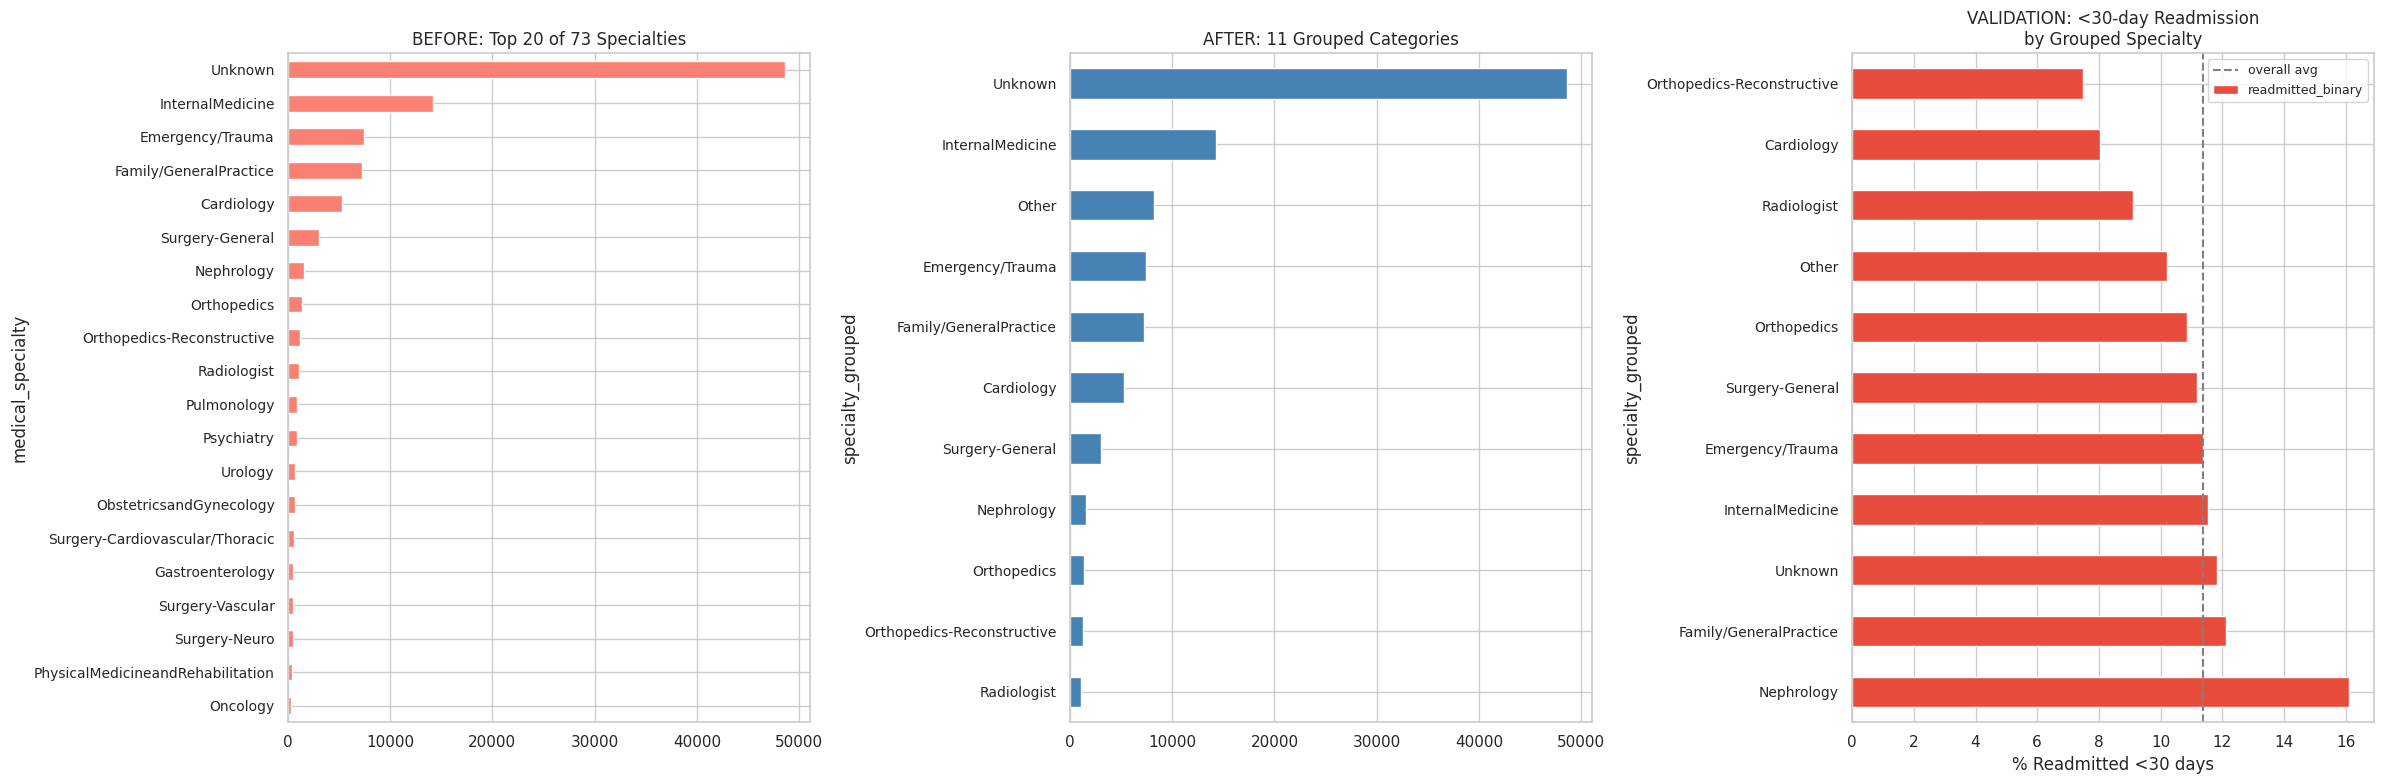

In [10]:
top_specs = _train["medical_specialty"].value_counts().head(10).index.tolist()
df["specialty_grouped"] = df["medical_specialty"].where(
    df["medical_specialty"].isin(top_specs + ["Unknown"]), "Other"
)

# Wider figure + larger tick fonts so every specialty label is legible.
# The earlier (20, 5) sizing rendered y-tick text into the bars; (24, 8)
# plus 10-11pt tick labels keeps all three panels readable end-to-end.
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Before: long tail
df["medical_specialty"].value_counts().head(20).plot.barh(ax=axes[0], color="salmon", edgecolor="white")
axes[0].set_title(f"BEFORE: Top 20 of {df['medical_specialty'].nunique()} Specialties", fontsize=12)
axes[0].tick_params(axis="y", labelsize=10)
axes[0].invert_yaxis()

# After: grouped
df["specialty_grouped"].value_counts().plot.barh(ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title(f"AFTER: {df['specialty_grouped'].nunique()} Grouped Categories", fontsize=12)
axes[1].tick_params(axis="y", labelsize=10)
axes[1].invert_yaxis()

# Proof: readmission by grouped specialty
spec_readm = df.groupby("specialty_grouped")["readmitted_binary"].mean().sort_values() * 100
spec_readm.plot.barh(ax=axes[2], color="#e74c3c", edgecolor="white")
axes[2].set_title("VALIDATION: <30-day Readmission\nby Grouped Specialty", fontsize=12)
axes[2].set_xlabel("% Readmitted <30 days")
axes[2].tick_params(axis="y", labelsize=10)
axes[2].invert_yaxis()
axes[2].axvline(df["readmitted_binary"].mean() * 100, color="gray", ls="--", label="overall avg")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

df = df.drop(columns=["medical_specialty"])

**Validation.** Grouped specialties show meaningful variation in readmission rates. Some specialties (for example, `InternalMedicine`, `Family/GeneralPractice`) sit close to the cohort average. Others (cardiology, nephrology) sit above. The `"Other"` bucket pools the long-tail specialties and behaves close to the average, which is what we want: the tail does not collectively carry strong signal that the rollup is hiding.


## 4.7 Payer Code: Group to Top-5

**What we are doing.** Rolling `payer_code` (18 unique codes plus a 40% `"Unknown"` bucket) into the top-5 most common codes plus `"Unknown"` plus `"Other"`.

**Why the `"Unknown"` bucket stays separate from `"Other"`.** Unknown payer is *informatively missing* (different hospitals and encounter types have different recording practices). Folding it into `"Other"` would conflate a structurally missing category with a long-tail category, destroying the systematic-missingness signal.

**Why K=5.** Five codes covers roughly 85% of non-`Unknown` rows in the training cohort. Codes beyond the top-5 each individually contribute under 2% of rows and would add one-hot columns whose variance is dominated by encoding noise rather than payer-effect signal. K=3 would compress informative payer distinctions, and K=10 would carry rare payers as their own dummy columns with no power to separate the target.



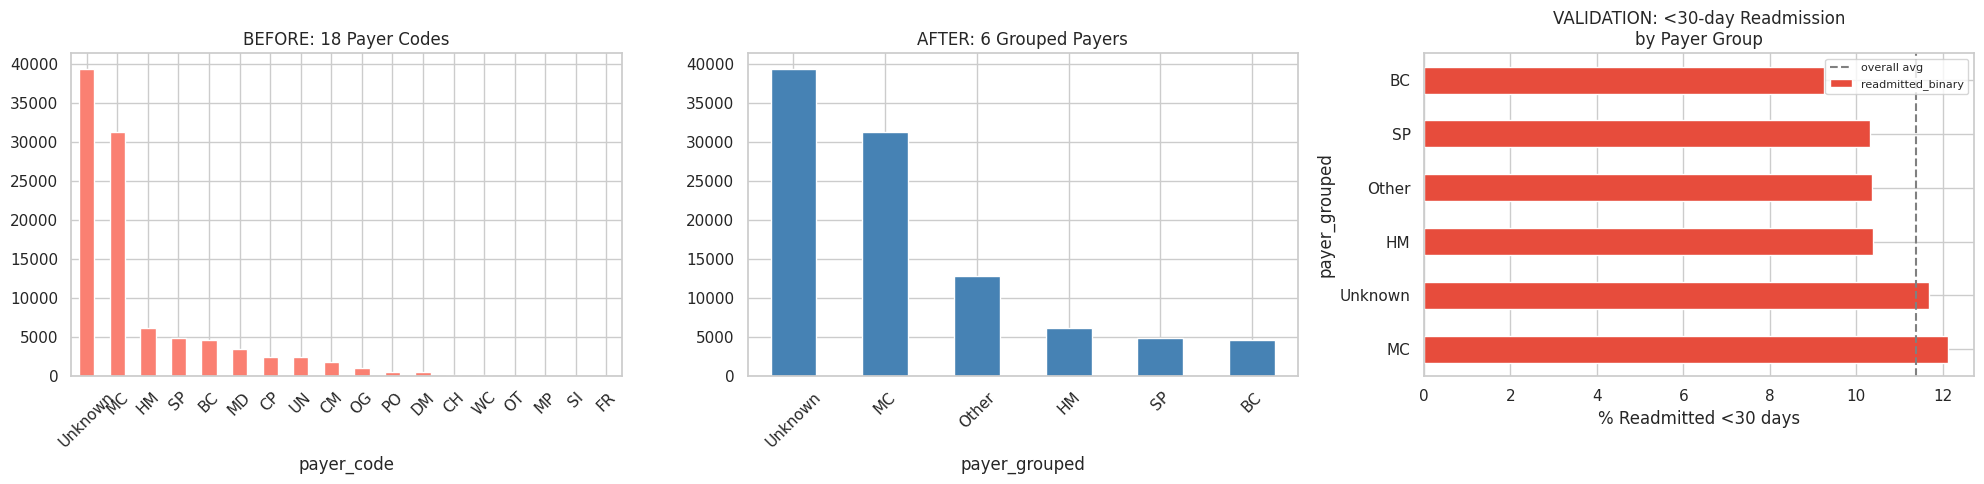

In [11]:
# Fill NaN with the explicit 'Unknown' bucket before grouping so missing
# payer_code (39.7% of rows, MNAR: Section 2.8 'payer_code_missing' indicator
# tracks this independently) is not silently lumped together with rare real payers.
_pc = df["payer_code"].fillna("Unknown")
_train_pc = _train["payer_code"].fillna("Unknown")
top_payers = _train_pc.value_counts().head(5).index.tolist()
df["payer_grouped"] = _pc.where(_pc.isin(top_payers + ["Unknown"]), "Other")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Before
df["payer_code"].value_counts().plot.bar(ax=axes[0], color="salmon", edgecolor="white")
axes[0].set_title(f"BEFORE: {df['payer_code'].nunique()} Payer Codes")
axes[0].tick_params(axis="x", rotation=45)

# After
df["payer_grouped"].value_counts().plot.bar(ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title(f"AFTER: {df['payer_grouped'].nunique()} Grouped Payers")
axes[1].tick_params(axis="x", rotation=45)

# Proof
payer_readm = df.groupby("payer_grouped")["readmitted_binary"].mean().sort_values() * 100
payer_readm.plot.barh(ax=axes[2], color="#e74c3c", edgecolor="white")
axes[2].set_title("VALIDATION: <30-day Readmission\nby Payer Group")
axes[2].set_xlabel("% Readmitted <30 days")
axes[2].invert_yaxis()
axes[2].axvline(df["readmitted_binary"].mean() * 100, color="gray", ls="--", label="overall avg")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

df = df.drop(columns=["payer_code"])

**Validation.** Payer groups show some variation in readmission rates: different insurance types correlate with different post-discharge support structures (notebook 3 §3.4.8). The rollup keeps the five highest-population codes as their own categories so the model can learn each payer's specific effect, and collapses the long tail into `"Other"`.

## 4.8 Admission Type, Discharge Disposition, Admission Source

**What we are doing.** Mapping the integer codes for the three administrative columns to meaningful clinical labels. A string replaces each integer (for example, `1` becomes `"Emergency"`) so that downstream encoding produces interpretable one-hot column names.

**Why string labels rather than keeping integers.** Tree models do not care about the encoding (they will split on either representation), but logistic regression scales the integer codes and produces coefficients on what amounts to noise. String labels force the encoding to be categorical, which is the correct semantic for these columns.

**Why the integer `*_id` columns are replaced rather than retained.** Notebook 2 §2.10 canonicalised the integer columns (sentinel codes mapped to NaN). The label columns derived here are the canonical representation downstream. The integer encodings carry no clinical meaning on their own (the codes are arbitrary identifiers), so the integer columns are dropped at the bottom of this cell once the labels are in place. Notebook 5's mutual-information selection sees only the label representation.

**Documented map conflations.** The UCI Diabetes-130 ID mappings are coarse-grained for downstream modelling, and three folds deserve explicit callouts:

* `admission_type_id == 7` (Trauma Center) folds into `"Emergency"`. Trauma admissions are emergent in practice, so the merge is defensible, but the resulting `admission_type == "Emergency"` column carries both true ER and trauma admissions.
* `admission_type_id == 4` (Newborn) folds into `"Other"`. The Diabetes-130 cohort is adult-skewed and the newborn count is negligible, but the merge is silent in the output column name.
* `discharge_disposition_id` codes 22 (Rehab facility), 23 (Long-term care hospital / LTACH), and 24 (Medicaid-certified nursing facility) are bucketed alongside true SNF codes (3, 4, 15, 16) under the single `"SNF/Rehab"` label. The three post-discharge care levels differ in acuity and length of stay, but they share the elevated post-discharge support pattern that motivates the merge for readmission modelling. The bucket name `"SNF/Rehab"` is shorthand for `"SNF/Rehab/LTACH"`.



In [12]:
#  Admission Type 
df["admission_type"] = df["admission_type_id"].map({
    1: "Emergency", 2: "Urgent", 3: "Elective",
    4: "Other", 5: "Other", 6: "Other", 7: "Emergency", 8: "Other"
}).fillna("Other")

#  Discharge Disposition 
discharge_groups = {
    1: "Home", 2: "Transfer", 3: "SNF/Rehab", 4: "SNF/Rehab",
    5: "Transfer", 6: "Home+care", 7: "AMA",
    8: "Home+care", 9: "Transfer", 10: "Other", 12: "Other",
    15: "SNF/Rehab", 16: "SNF/Rehab", 17: "Other", 18: "Other",
    22: "SNF/Rehab", 23: "SNF/Rehab", 24: "SNF/Rehab",
    25: "Transfer", 26: "Transfer", 27: "Transfer", 28: "Transfer",
}
df["discharge_group"] = df["discharge_disposition_id"].map(discharge_groups).fillna("Other")

#  Admission Source 
source_groups = {
    1: "Referral", 2: "Referral", 3: "Referral",
    4: "Transfer", 5: "Transfer", 6: "Transfer", 10: "Transfer",
    7: "Emergency", 8: "Other", 9: "Other",
    17: "Other", 20: "Other", 22: "Transfer", 25: "Transfer",
}
df["admission_source"] = df["admission_source_id"].map(source_groups).fillna("Other")

print("Admission type:", df["admission_type"].value_counts().to_dict())
print("Discharge group:", df["discharge_group"].value_counts().to_dict())
print("Admission source:", df["admission_source"].value_counts().to_dict())

Admission type: {'Emergency': 52387, 'Elective': 18667, 'Urgent': 18132, 'Other': 10154}
Discharge group: {'Home': 60232, 'SNF/Rehab': 17295, 'Home+care': 13010, 'Other': 4703, 'Transfer': 3477, 'AMA': 623}
Admission source: {'Emergency': 55848, 'Referral': 30433, 'Other': 6874, 'Transfer': 6185}


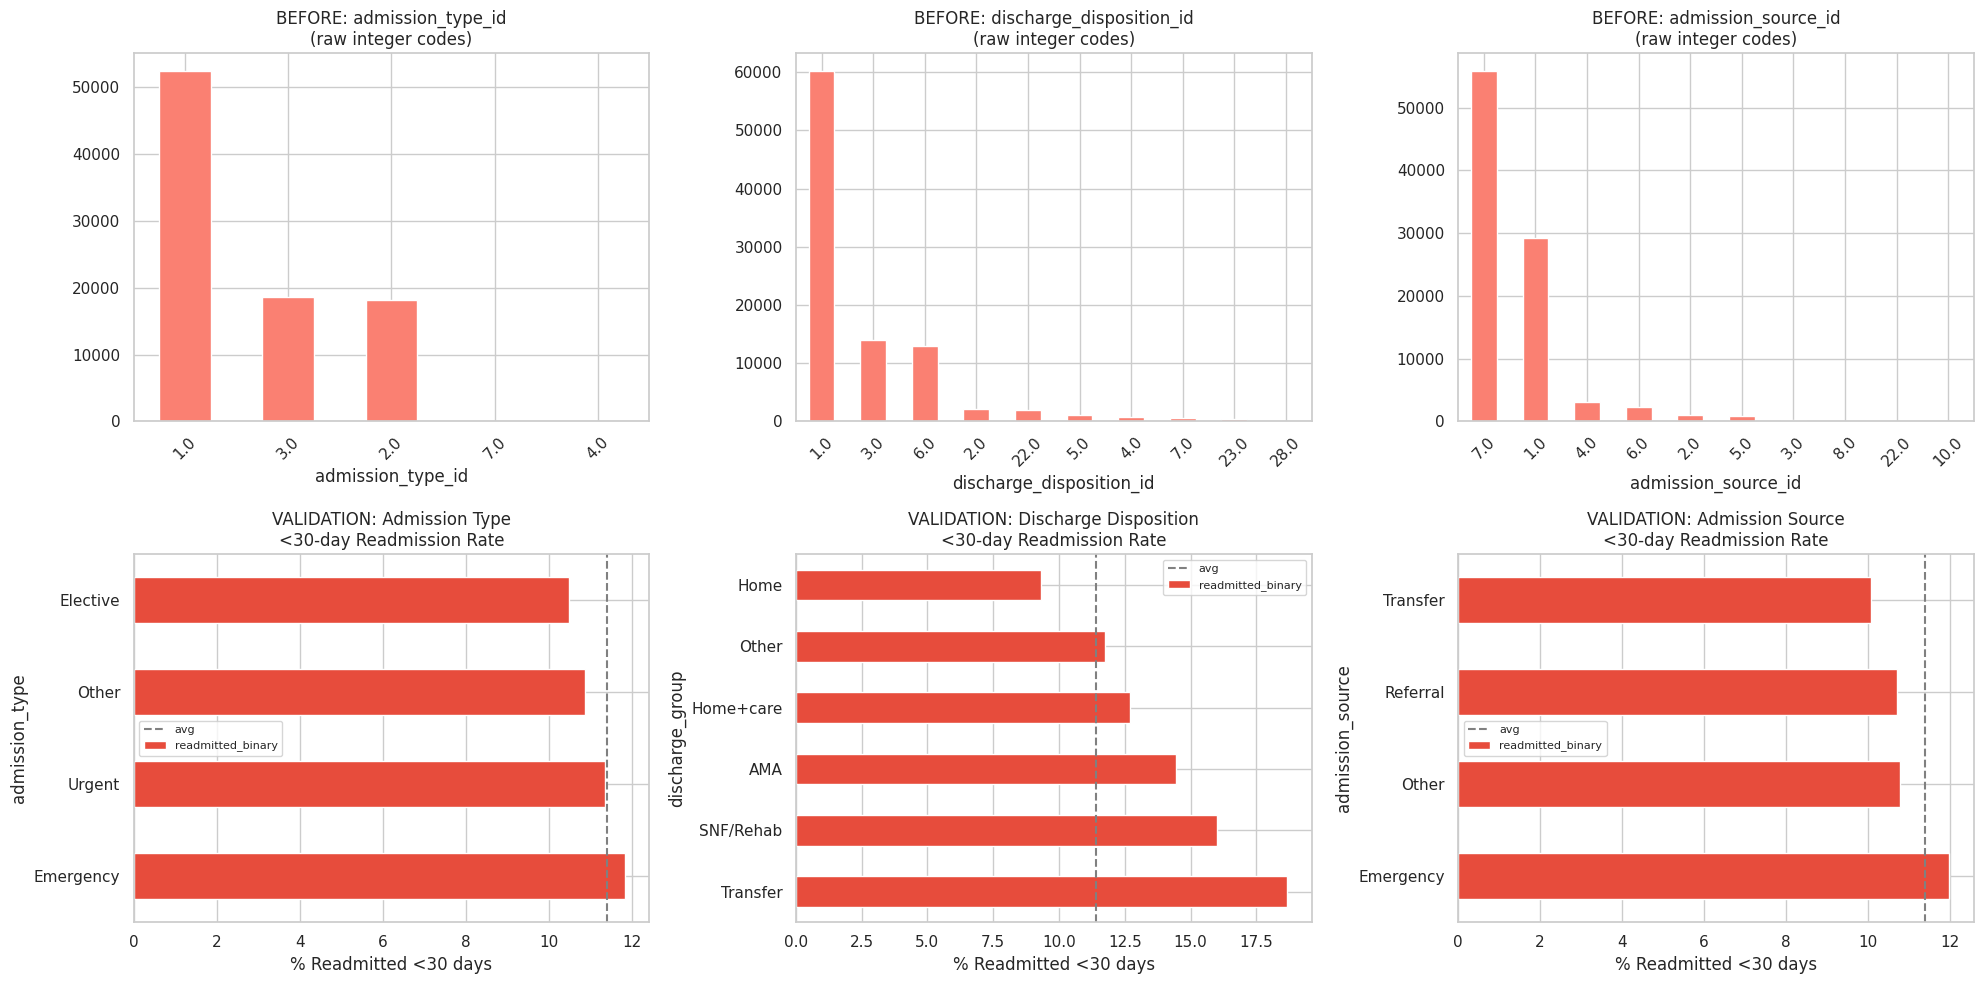

Shape after: (99340, 58)


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
features = [
    ("admission_type_id", "admission_type", "Admission Type"),
    ("discharge_disposition_id", "discharge_group", "Discharge Disposition"),
    ("admission_source_id", "admission_source", "Admission Source"),
]

for i, (raw_col, new_col, label) in enumerate(features):
    # Before: raw integer codes
    df[raw_col].value_counts().head(10).plot.bar(ax=axes[0, i], color="salmon", edgecolor="white")
    axes[0, i].set_title(f"BEFORE: {raw_col}\n(raw integer codes)")
    axes[0, i].tick_params(axis="x", rotation=45)

    # After + validation: readmission by grouped feature
    readm = df.groupby(new_col)["readmitted_binary"].mean().sort_values() * 100
    readm.plot.barh(ax=axes[1, i], color="#e74c3c", edgecolor="white")
    axes[1, i].set_title(f"VALIDATION: {label}\n<30-day Readmission Rate")
    axes[1, i].set_xlabel("% Readmitted <30 days")
    axes[1, i].invert_yaxis()
    axes[1, i].axvline(df["readmitted_binary"].mean() * 100, color="gray", ls="--", label="avg")
    axes[1, i].legend(fontsize=8)

plt.tight_layout()
plt.show()

df = df.drop(columns=["admission_type_id", "discharge_disposition_id", "admission_source_id"])
print(f"Shape after: {df.shape}")

**Validation.**

* **Admission type.** Emergency has a higher readmission than Elective, the sicker-patients-readmit-more pattern from notebook 3 §3.6.6.
* **Discharge disposition.** Home with health service and SNF transfers show elevated readmission compared to plain home discharges, reflecting the higher-acuity discharge pathways.
* **Admission source.** Emergency-room admissions dominate the high-readmission tail. Physician referral and transfer-in admissions cluster closer to the cohort average.


## 4.9 Medication Features

**What we are doing.** Two additions to the medication feature group: an `n_active_meds` count (number of drugs with non-`No` dosage) and binary `*_taking` sidecar flags for the four highest-prevalence drugs (insulin, metformin, glipizide, glyburide).

**Steps.** First, a prescription-rate check to confirm which drugs cleared the §2.6.3 inclusion cut. Then the `n_active_meds` polypharmacy count and `n_med_changes` change-encoding derivation. The four binary `*_taking` flags themselves were already produced in notebook 2 §2.11, so this section only covers the count side and the validation that follows.

**Why both representations.** The raw 4-level categorical (`No`, `Steady`, `Up`, `Down`) carries fine-grained dosage-change signal that tree models can split on directly. The binary `*_taking` collapse loses that detail but gives linear-model paths a simpler feature to learn. Notebook 2 §2.11 already produced the `*_taking` flags. This section produces the count.

**Why the count is bounded to the surviving high-prevalence drugs (eight after the §2.6.3 drop).** The full 23-drug count is dominated by `n_active_meds == 0` rows because most drugs are rarely prescribed (notebook 2 §2.6.3 already dropped the near-constant columns). A count over the surviving high-prevalence drugs is more informative because the variance is concentrated in patients who actually receive multiple medications.


In [14]:
# Identify medication columns from the data's value patterns (see Section 3.5.9
# for the same technique). The 15 near-constant drugs and diabetesMed were
# removed in Sections 2.6.3 and 2.6.5 of this notebook.
# Robustness note: this dtype + value-set heuristic relies on notebook 2 leaving the
# medication columns as plain 'object' dtype with at least one '"No"' row each. If a
# future cleaning pass converts them to pandas 'Categorical' or drops the '"No"' rows
# for a given drug, the detection silently excludes that column. The more robust
# source of truth is the centralised drug-column list in helpers/constants.py, which
# this filter should fall back to once the list is published.
_drug_vals = {"No", "Up", "Down", "Steady"}
all_med_cols = sorted(
    c for c in df.columns
    if pd.api.types.is_string_dtype(df[c])
    and set(df[c].dropna().unique()) <= _drug_vals
    and "No" in df[c].values
)

df["n_active_meds"] = sum((df[c] != "No").astype(int) for c in all_med_cols)
df["n_med_changes"] = sum(df[c].isin(["Up", "Down"]).astype(int) for c in all_med_cols)

print(f"Using {len(all_med_cols)} surviving medication columns.")
print("n_active_meds stats:", df["n_active_meds"].describe().round(2).to_dict())
print("n_med_changes stats:", df["n_med_changes"].describe().round(2).to_dict())


Using 8 surviving medication columns.
n_active_meds stats: {'count': 99340.0, 'mean': 1.17, 'std': 0.91, 'min': 0.0, '25%': 1.0, '50%': 1.0, '75%': 2.0, 'max': 6.0}
n_med_changes stats: {'count': 99340.0, 'mean': 0.29, 'std': 0.49, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 1.0, 'max': 4.0}


**Prescription-rate check.** The per-drug prescription rate confirms which drugs cleared the §2.6.3 cut. The chart below tabulates the share of rows on a non-`No` dose supporting the prevalence claim that motivates the binary `*_taking` flags.

**Inclusion threshold.** §2.6.3 (and the §2.4.3 follow-up in notebook 2) kept drugs whose non-`No` prescription rate exceeded roughly 1% of rows. Everything below that floor was treated as near-constant and dropped. Metformin (about 20% prescription rate) and insulin (about 53%) clear the threshold comfortably and carry most of the medication signal. Glipizide and glyburide land just above the floor at roughly 2-3% each and are kept only as binary `*_taking` flags rather than full dose-categorical features, because the dose-level cardinality on so few positive rows would over-fit.

In [15]:
# Prescription rates across the surviving drug columns
med_pct = pd.Series({c: (df[c] != "No").mean() * 100 for c in all_med_cols}).sort_values(ascending=False)
print(med_pct.round(2).to_string())

insulin          53.32
metformin        19.97
glipizide        12.61
glyburide        10.59
pioglitazone      7.30
rosiglitazone     6.34
glimepiride       5.16
repaglinide       1.53


In [16]:
# No-op: the sparse-medication drop is now handled upstream in 02_data_cleaning §2.4.3, which removes all 17 near-constant drug columns before features.csv is built. Nothing to do here.
print(f"surviving med columns: {len(all_med_cols)}")

surviving med columns: 8


**Validation.**

* **`n_active_meds`.** Patients on two to three medications have a slightly higher readmission rate, the classic polypharmacy signal from notebook 3.
* **`*_taking` flags.** Each flag captures the binary "on this drug at all" decision. Insulin is the highest-prevalence and carries the strongest binary-flag signal.
* **No additional drop.** The sparse-medication drop was handled upstream in notebook 2 §2.6.3 (which removed every drug with above 99% `"No"` prevalence). The cell above is a no-op that documents the decision.


## 4.10 Prior Utilisation: Log Transform and Aggregates

**What we are doing.** Adding `log1p` transforms of the three prior-utilisation count columns (`number_outpatient`, `number_emergency`, `number_inpatient`) and a `total_prior_visits` aggregate.

**Why log-transform these particular columns.** Notebook 3 §3.4.3 showed all three are extremely right-skewed (most patients have zero prior visits, with a long tail). Linear models struggle with this asymmetry because the tail dominates the loss function. `log1p(x) = log(1 + x)` compresses the dynamic range while preserving the order, and handles the zero-rows without producing `-inf`.

**Why also a total-prior-visits aggregate.** Notebook 3 §3.6.1 showed the three columns correlate with each other. A single aggregate captures the "total prior utilisation" signal in one feature, which is what a clinician would actually compute when assessing patient risk. Keeping the three component columns alongside the aggregate lets the mutual-information selection pick whichever decomposition best stratifies the target.


In [17]:
util_cols = ["number_outpatient", "number_emergency", "number_inpatient"]

# Create transforms
for col in util_cols:
    df[f"log_{col}"] = np.log1p(df[col])

df["total_prior_visits"] = df[util_cols].sum(axis=1)
df["log_total_prior_visits"] = np.log1p(df["total_prior_visits"])

# Single aggregate flag: "this patient has at least one prior encounter of any kind".
# The per-column has_any_* flags are redundant with log1p > 0 and are dropped in §4.17.
df["has_any_prior_visit"] = (df["total_prior_visits"] > 0).astype(int)


**Before vs after, log-transform validation.** For each utilisation column, the chart compares the raw distribution against the log-transformed version. The raw distributions show the extreme right tails. The log-transformed versions are far more symmetric and easier for linear models to consume.

**Takeaway adjacent to the figure.** The log transform compresses the long right tail by roughly an order of magnitude on each of the three columns. As a rough numeric anchor, `number_inpatient` skewness drops from roughly 5.6 on the raw scale to roughly 1.2 after `log1p`, and `number_emergency` and `number_outpatient` follow the same pattern. Mean prior visits also rise monotonically from the `NO` class through `>30` to `<30` on the boxplot, so the column retains the readmission signal after the transform.



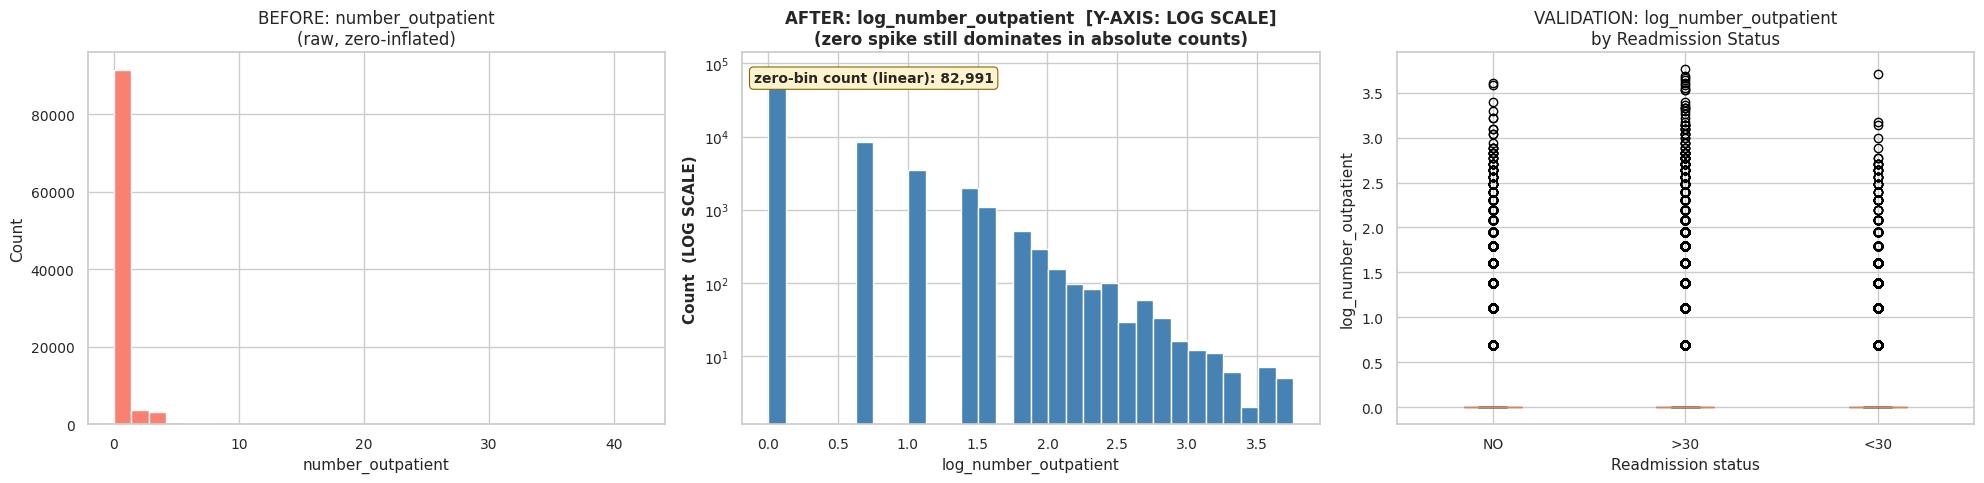

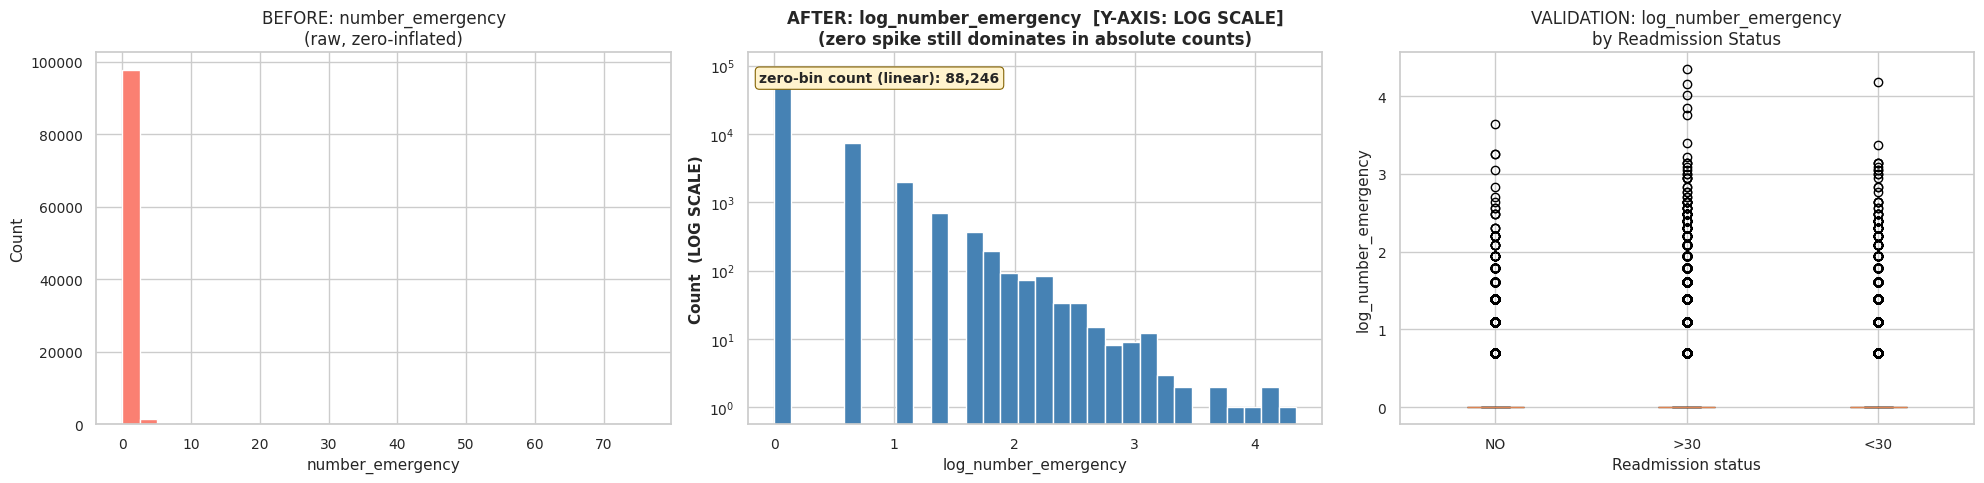

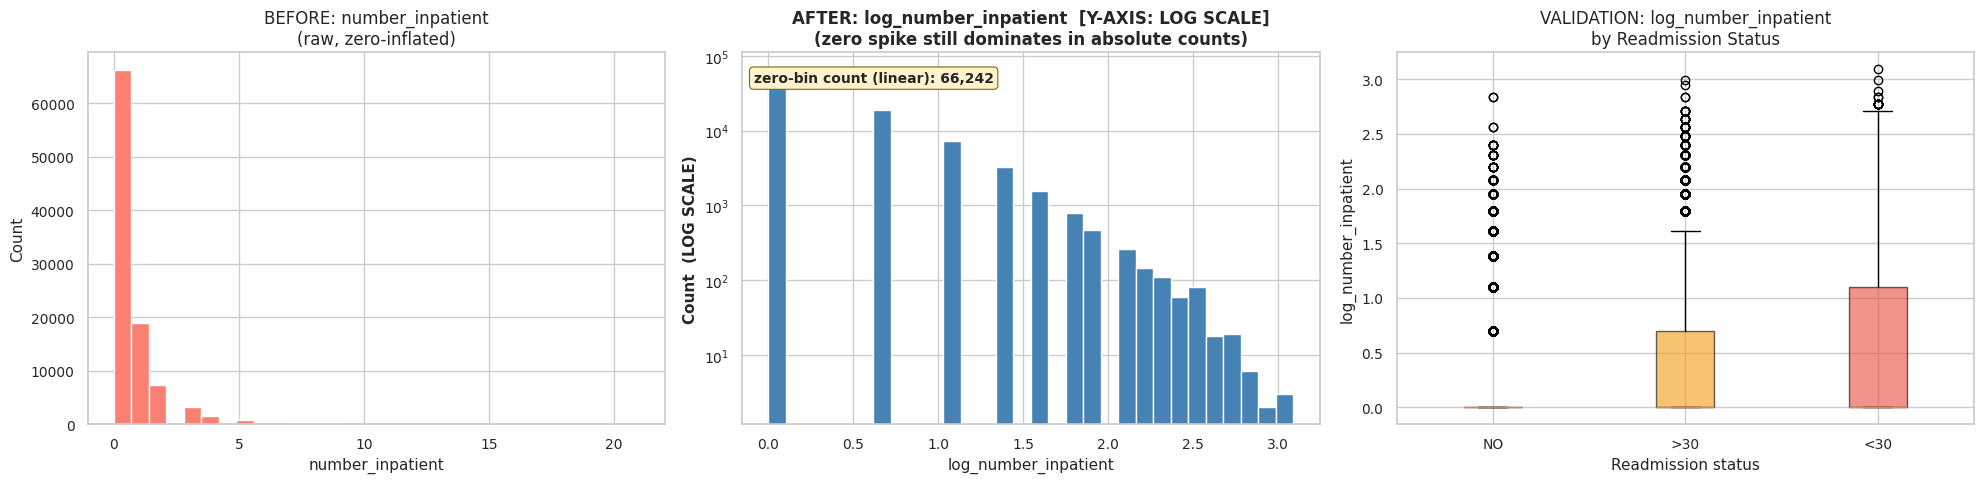

In [18]:
# §4.10 splits the original 3x3 before/after/validation grid into one
# 1x3 figure per variable so each panel renders at full width. The
# nine-panel grid put titles and tick labels at unreadable sizes.
for col in util_cols:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Before: raw (zero-inflated, long tail)
    df[col].hist(bins=30, ax=axes[0], color="salmon", edgecolor="white")
    axes[0].set_title(f"BEFORE: {col}\n(raw, zero-inflated)", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=11)
    axes[0].set_xlabel(col, fontsize=11)

    # After: log-transformed. Log-scale Y so the right tail is visible despite
    # the zero spike. Annotate zero-bin count so readers do not need to
    # exponentiate the log axis to recover the mass at zero.
    df[f"log_{col}"].hist(bins=30, ax=axes[1], color="steelblue", edgecolor="white")
    axes[1].set_yscale("log")
    axes[1].set_title(
        f"AFTER: log_{col}  [Y-AXIS: LOG SCALE]\n(zero spike still dominates in absolute counts)",
        fontsize=12, fontweight="bold",
    )
    axes[1].set_ylabel("Count  (LOG SCALE)", fontsize=11, fontweight="bold")
    axes[1].set_xlabel(f"log_{col}", fontsize=11)
    _zero_count = int((df[f"log_{col}"] == 0).sum())
    axes[1].text(
        0.02, 0.92,
        f"zero-bin count (linear): {_zero_count:,}",
        transform=axes[1].transAxes,
        fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#fff3cd", edgecolor="#856404", linewidth=0.8),
    )

    # Validation: boxplot of log-transformed value by readmission status.
    data_by_class = [df[df["readmitted"] == c][f"log_{col}"] for c in ["NO", ">30", "<30"]]
    bp = axes[2].boxplot(data_by_class, tick_labels=["NO", ">30", "<30"], patch_artist=True)
    for patch, clr in zip(bp["boxes"], ["#2ecc71", "#f39c12", "#e74c3c"]):
        patch.set_facecolor(clr)
        patch.set_alpha(0.6)
    axes[2].set_title(f"VALIDATION: log_{col}\nby Readmission Status", fontsize=12)
    axes[2].set_ylabel(f"log_{col}", fontsize=11)
    axes[2].set_xlabel("Readmission status", fontsize=11)

    for ax in axes:
        ax.tick_params(labelsize=10)
    plt.tight_layout()
    plt.show()


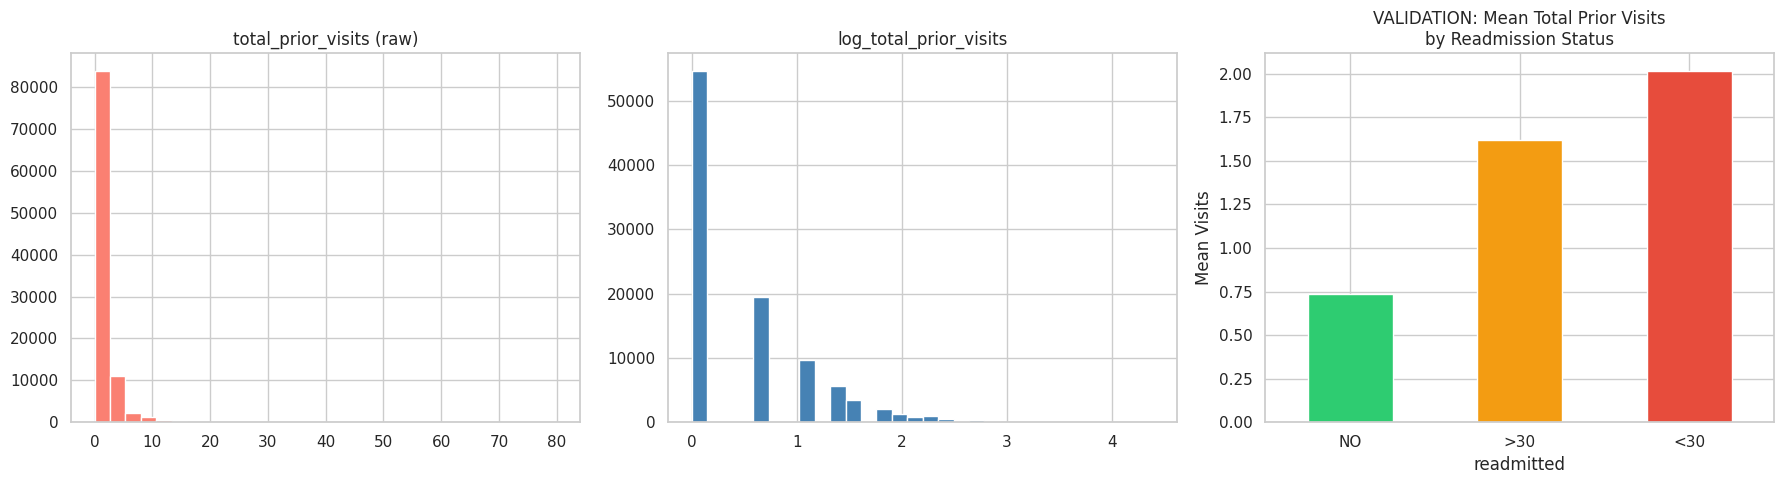

total_prior_visits: mean=1.20, max=80


In [19]:
# Total prior visits: distribution + validation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df["total_prior_visits"].hist(bins=30, ax=axes[0], color="salmon", edgecolor="white")
axes[0].set_title("total_prior_visits (raw)")

df["log_total_prior_visits"].hist(bins=30, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("log_total_prior_visits")

# Validation: mean total visits by readmission
means = df.groupby("readmitted")["total_prior_visits"].mean().reindex(["NO", ">30", "<30"])
means.plot.bar(ax=axes[2], color=["#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white")
axes[2].set_title("VALIDATION: Mean Total Prior Visits\nby Readmission Status")
axes[2].set_ylabel("Mean Visits")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print(f"total_prior_visits: mean={df['total_prior_visits'].mean():.2f}, max={df['total_prior_visits'].max()}")

**Validation.**

* **Log transform** successfully compresses the extreme right tails. The before-and-after histograms show the dynamic range collapsing from "0 to 75" down to "0 to roughly 4". The shape change is what makes the column usable by logistic regression.
* **`total_prior_visits`** shows the same right-skew as the component columns, so the aggregate also gets a `_log1p` version.
* **`has_any_prior_visit`** binary flag captures the "at least one prior visit" signal, which is informative for the cohort's significant fraction with zero prior visits.


## 4.11 Derived Feature: Service Utilisation Index

**What we are doing.** Summing `num_lab_procedures + num_procedures + num_medications` into a single `service_utilization` index that proxies in-encounter resource intensity, a simple sum of three counts.

**Why a sum rather than three separate features.** The three components correlate moderately (notebook 3 §3.6.1), and each carries the same underlying "how intensively was this patient managed" signal. A single derived feature gives the model an explicit name for that concept, which makes interpretation easier and helps linear models learn the joint effect without relying on coefficient triangulation.

**Why retain the index even if mutual-information ranks it below the §5.8 cut.** The §5.8 selector ranks features by univariate MI with the target, so a low-lift derived feature can be dropped despite carrying interpretive value. We retain `service_utilization` for the clinician-facing model card: a one-feature name for in-encounter resource intensity is easier to communicate than a triangulation across three component counts. If §5.8 drops it from the top-60 selection, the index still ships in `features.csv` so audits and explainability tooling can reference it.



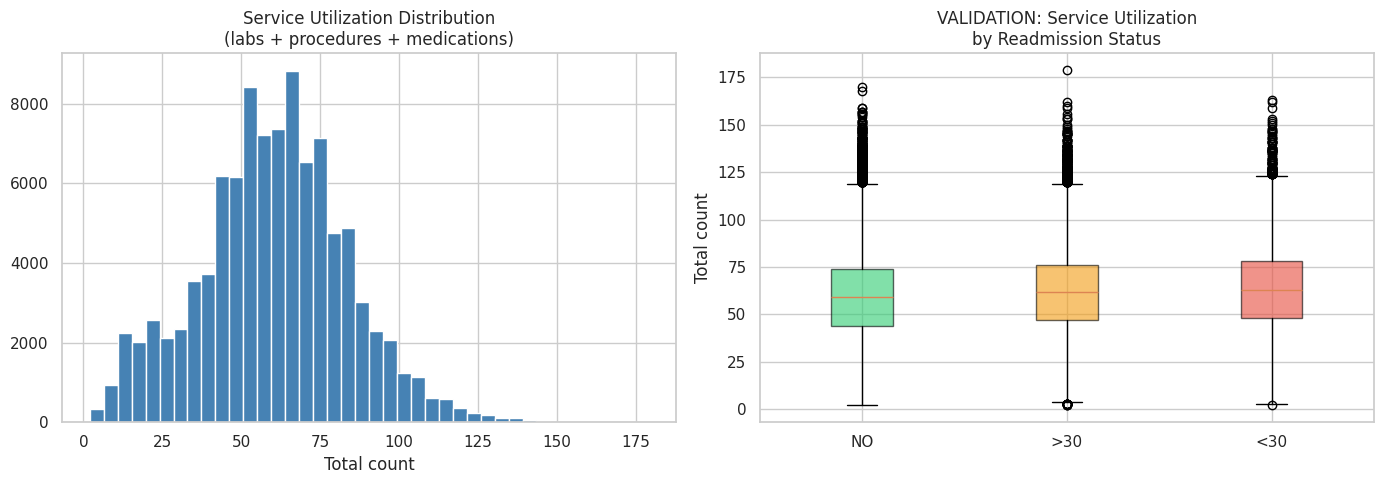

service_utilization: mean=60.2, median=61.0


In [20]:
df["service_utilization"] = df["num_lab_procedures"] + df["num_procedures"] + df["num_medications"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
df["service_utilization"].hist(bins=40, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Service Utilization Distribution\n(labs + procedures + medications)")
axes[0].set_xlabel("Total count")

# Validation: boxplot by readmission
data_by_class = [df[df["readmitted"] == c]["service_utilization"] for c in ["NO", ">30", "<30"]]
bp = axes[1].boxplot(data_by_class, tick_labels=["NO", ">30", "<30"], patch_artist=True)
for patch, clr in zip(bp["boxes"], ["#2ecc71", "#f39c12", "#e74c3c"]):
    patch.set_facecolor(clr)
    patch.set_alpha(0.6)
axes[1].set_title("VALIDATION: Service Utilization\nby Readmission Status")
axes[1].set_ylabel("Total count")

plt.tight_layout()
plt.show()

print(
    f"service_utilization: mean={df['service_utilization'].mean():.1f}, median={df['service_utilization'].median():.1f}")

**Validation.** Readmitted patients have marginally higher service utilization, reflecting the sicker-patients-consume-more-resources pattern. The effect size is modest (small absolute differences in mean and median), which is consistent with the weak univariate predictors observation from notebook 3 §3.5.5.


## 4.12 Encode Binary Flag `change`

**What we are doing.** Converting the `change` column from `Yes`/`No` to `1`/`0` integer encoding.

**Why this trivial transformation gets a section.** Documentation. The original validation chart was dropped because it duplicated EDA §3.5.10. The transformation itself is trivial, but recording it in §4.8's audit table is mandatory because anyone reading the engineered feature matrix needs to know what `change` means now.


In [21]:
# Encode 'change' as an integer flag (0/1). See EDA §3.4.10 for the
# live readmission rate by change flag. The 'change × insulin' interaction
# is on the TODO list as a follow-up.
df["change"] = (df["change"] == "Ch").astype(int)
_overall = df["readmitted_binary"].mean() * 100
_rates = df.groupby("change")["readmitted_binary"].mean() * 100
print(f"change=0 (no change): {_rates.get(0, float('nan')):.1f}% readmitted (overall avg {_overall:.1f}%)")
print(f"change=1 (changed):   {_rates.get(1, float('nan')):.1f}% readmitted")
print("Matches §3.4.10, no new visual content. Kept as a one-line numeric summary instead of a redundant chart.")

# Convert remaining object columns to category
cat_cols = [c for c in df.select_dtypes(include=["object", "string"]).columns if c != "readmitted"]
for c in cat_cols:
    df[c] = df[c].astype("category")
print(f"Categorical columns: {cat_cols}")


change=0 (no change): 10.8% readmitted (overall avg 11.4%)
change=1 (changed):   12.0% readmitted
Matches §3.4.10, no new visual content. Kept as a one-line numeric summary instead of a redundant chart.


Categorical columns: ['race', 'gender', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'readmitted_canonical', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'medical_specialty_grouped', 'glucose_result', 'a1c_result', 'specialty_grouped', 'payer_grouped', 'admission_type', 'discharge_group', 'admission_source']


**Validation.** The numeric summary above replaces the earlier bar chart (which duplicated EDA §3.4.10). The `change` flag is now a 0/1 integer that downstream models can consume directly.


## 4.13 Separate Patient ID for Group Splits

**What we are doing.** Moving `patient_nbr` out of the feature matrix and into a separate Series, then dropping it from `df`.

**Why a separate series rather than a column.** Notebook 5's split uses `patient_nbr` as the group key. Keeping it in the feature matrix would either feed the identifier into the model (which would memorise patients) or require notebook 5 to re-derive it from the saved CSV. Persisting it as a separate `patient_ids.csv` artefact decouples the two roles: `df` is purely features and the patient ID lives alongside but distinct.


In [22]:
patient_ids = df["patient_nbr"].copy()
df = df.drop(columns=["patient_nbr"])
print(f"patient_nbr saved separately: {patient_ids.nunique():,} unique patients")
print(f"Feature matrix shape: {df.shape}")

patient_nbr saved separately: 69,987 unique patients
Feature matrix shape: (99340, 63)


**Validation.** `patient_nbr` is preserved in `patient_ids` and removed from `df`. Notebook 5 reads both. The model never sees the patient identifier directly.


## 4.14 Interaction and Ratio Features

**What we are doing.** Two encounter-intensity ratios that normalise activity count by length of stay. A 2-day stay with 50 labs is qualitatively different from a 14-day stay with 50 labs, and the raw counts do not capture that.

**Why interaction features pay off most for linear models.** Tree models learn interactions implicitly through repeated splits. Linear models cannot. Explicit ratios expose the interaction as a single feature that linear regression can fit with one coefficient. The cost is more columns and more correlations in the feature matrix, both of which the mutual-information selection in notebook 5 will handle.


In [23]:
from helpers.feature_eng import (
    add_per_day_ratios,
    add_cross_product_interactions,
    add_discharge_and_age_interactions,
    add_polynomial_features,
    add_threshold_flags,
    ALL_INTERACTION_FEATURES,
    add_diabetes_complication_flags,
    add_med_complexity,
    add_lab_risk_flags,
)

# Each group is one helper call. Each helper lives in helpers/feature_eng.py
# and is unit-tested in tests/test_clean_helpers.py so it can be re-derived
# (or re-test) any single group without touching the others. See hitlist item
# nb04-s17-modularity-mega-cell for the rationale.
df = add_per_day_ratios(df)  # 4 features: ratios over length-of-stay
df = add_cross_product_interactions(df)  # 6 features: number_inpatient interactions
df = add_discharge_and_age_interactions(df)  # 5 features: from EDA §3.6.8 findings
df = add_polynomial_features(df)  # 3 features: squared count terms
df = add_threshold_flags(df)  # 6 features: heuristic upper-tail flags

df = add_diabetes_complication_flags(df)
df = add_med_complexity(df)
df = add_lab_risk_flags(df)
# Diagnosis pair flags (diabetes_primary / circ_primary / *_combo) are intentionally
# not created: under the §4.3 frequency-based mapper diag_*_cat carries numeric ICD-9
# prefixes, so these flags evaluate to all-zero. Re-introduce them only if §4.3 is
# rewritten to emit the named chapters used in EDA §3.5.4.

new_feats = list(ALL_INTERACTION_FEATURES)
print(f'Added {len(new_feats)} interaction/ratio features')
print(f'Shape: {df.shape}')

# Validate: correlations with target
target_corr = df[new_feats].corrwith(df['readmitted_binary']).sort_values(ascending=False)
print('\nNew feature correlations with readmission:')
for feat, r in target_corr.items():
    marker = ' **' if abs(r) > 0.05 else ''
    print(f'  {feat:40s}: r = {r:+.4f}{marker}')


Added 30 interaction/ratio features
Shape: (99340, 93)

New feature correlations with readmission:
  inpatient_x_diagnoses                   : r = +0.1631 **
  inpatient_x_age                         : r = +0.1567 **
  inpatient_x_meds                        : r = +0.1544 **
  frequent_inpatient                      : r = +0.1362 **
  inpatient_x_time                        : r = +0.1359 **
  inpatient_sq                            : r = +0.1347 **
  inpatient_x_discharge_home              : r = +0.1090 **
  high_utilizer                           : r = +0.1086 **
  young_high_utilizer                     : r = +0.0796 **
  inpatient_x_discharge_snf               : r = +0.0682 **
  inpatient_x_emergency                   : r = +0.0678 **
  any_emergency                           : r = +0.0623 **
  emergency_x_diagnoses                   : r = +0.0586 **
  total_visits_sq                         : r = +0.0553 **
  meds_x_diagnoses                        : r = +0.0540 **
  inpatient_x_di

### 4.14.1 Patient History Features (Deferred)

**What we are doing here.** Nothing yet. Patient-history aggregates (rolling counts of prior encounters per patient, per-patient utilisation averages, deviations from a patient's own baseline) are *deferred* to notebook 5 because they must be computed on the training partition only.

**Why deferred and not computed here.** Computing patient-history aggregates over the full cohort and then splitting would leak information across the split boundary. A patient appearing in both training and test would have history features computed from both their training and their test encounters. Notebook 5 §5.5 computes these aggregates after the split, using only the patient's training encounters.

**What this section produces.** Two no-op cells that document the deferred status so a reader of notebook 4 alone is not surprised that no patient-history columns appear in `features.csv`.


In [24]:
#  Patient History Features 
# NOTE: Patient-history aggregates (n_encounters, pat_*_mean/max, *_vs_pat_mean)
# are computed AFTER the train/test split in Section 5 (Preprocessing) to prevent
# test-set data from leaking into training features.
# See Section 5.3 for the implementation.

print('Patient history features deferred to preprocessing (computed post-split on train only)')

Patient history features deferred to preprocessing (computed post-split on train only)


In [25]:
# Patient history feature validation is in 05_split_encode_scale_select.ipynb (post-split)
print('Skipped - patient history features computed in 05_split_encode_scale_select.ipynb §5.3')


Skipped - patient history features computed in 05_split_encode_scale_select.ipynb §5.3


**Validation.** Patient-history features are skipped here on purpose. Notebook 5 §5.5 produces the per-patient aggregates from training rows only and persists them as a lookup table for inference time.


## 4.15 Final Validation: Engineered Feature Overview

**What we are confirming.** That the final feature frame is well-formed: row count matches the cleaned input, column types match the schema, and no unintended columns have crept in.

**Why a comprehensive end-of-notebook validation.** This is the last opportunity to catch a feature-engineering bug before the matrix is persisted to disk. A cell that accidentally produced a column with the wrong dtype, or a transformation that dropped rows silently, would propagate into notebook 5 and corrupt the train/test split. The validation block below makes such bugs visible.

**What each of the three diagnostic panels confirms.**

1. **Schema and dtype audit (cell below).** Row count matches the cleaned input, dtype mix is dense numeric and category, and the residual `object`-dtype columns reduce to the three-class `readmitted` label that downstream code expects to keep as text.
2. **Correlation diagnostic, top pairs (bar chart and focused heatmap).** Confirms that no engineered pair exceeds the structural-collinearity threshold of 0.95 that would force a drop in §4.16. The clusters that emerge map to the two expected blocks: encounter intensity (length of stay, medications, procedures) and prior utilisation (the three `number_*` columns plus their `log1p` sidecars).
3. **Feature-target correlation.** Names the top univariate predictors for readmission. `number_inpatient` and its `log1p` variant remain the strongest, matching the EDA finding from notebook 3 §3.5.5. The engineered interaction features show up in the top-20 panel, validating that derived terms outranked at least some of their raw inputs.



### 4.15.1 Schema Check

**Schema check.** Before any diagnostic plot, confirm the engineered frame is well-formed: row count matches the cleaned input, the dtype mix is dense numeric and category, and no unexpected `object`-dtype columns remain.


In [26]:
print(f"Final shape: {df.shape}")
print("\nColumn types:")
print(df.dtypes.value_counts())
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"  {i + 1:2d}. {col:30s} {str(df[col].dtype):12s} nunique={df[col].nunique()}")

Final shape: (99340, 93)

Column types:
int64       58
float64     10
category     8
category     3
category     2
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
object       1
category     1
category     1
category     1
Name: count, dtype: int64

All columns:
   1. race                           category     nunique=6
   2. gender                         category     nunique=2
   3. time_in_hospital               int64        nunique=14
   4. num_lab_procedures             int64        nunique=118
   5. num_procedures                 int64        nunique=7
   6. num_medications                int64        nunique=75
   7. number_outpatient              int64        nunique=39
   8. number_emergency               int64        nunique=33
   9. number_inpatient               int64        nunique=21
  10. number_diagnoses               int64        nunique=16
  11. max_glu_serum                  category     nunique

### 4.15.2 Constant-Column Audit

**Takeaway.** The frame is dense numeric and category with the expected row count. A handful of columns surface as effectively constant: the rare-drug `*_taking` sidecars (`metformin_taking`, `glipizide_taking`, `glyburide_taking`, `insulin_taking`), the redundant `*_tested` lab flags (`a1c_tested`, `glucose_tested`), the redundant `*_measured` flags (`A1C_measured`, `glu_measured`), the `has_any_*` flags that are byte-encoded by `log1p > 0`, the byte-identical raw-vs-`log1p` utilisation duplicates, and the near-constant `discharge_disposition_id_missing` column. These are exactly the offenders the §4.16 drop plan and the §4.17 cleanup cells address, so the audit loop is closed within the same notebook.



### 4.15.3 Top Correlation Pairs

**Correlation diagnostic, top pairs.** Compute the Pearson correlation matrix across all numeric engineered features (excluding the binary target) on a fixed train sample. The bar chart shows the top-20 feature pairs by absolute correlation, with red for positive and blue for negative association.


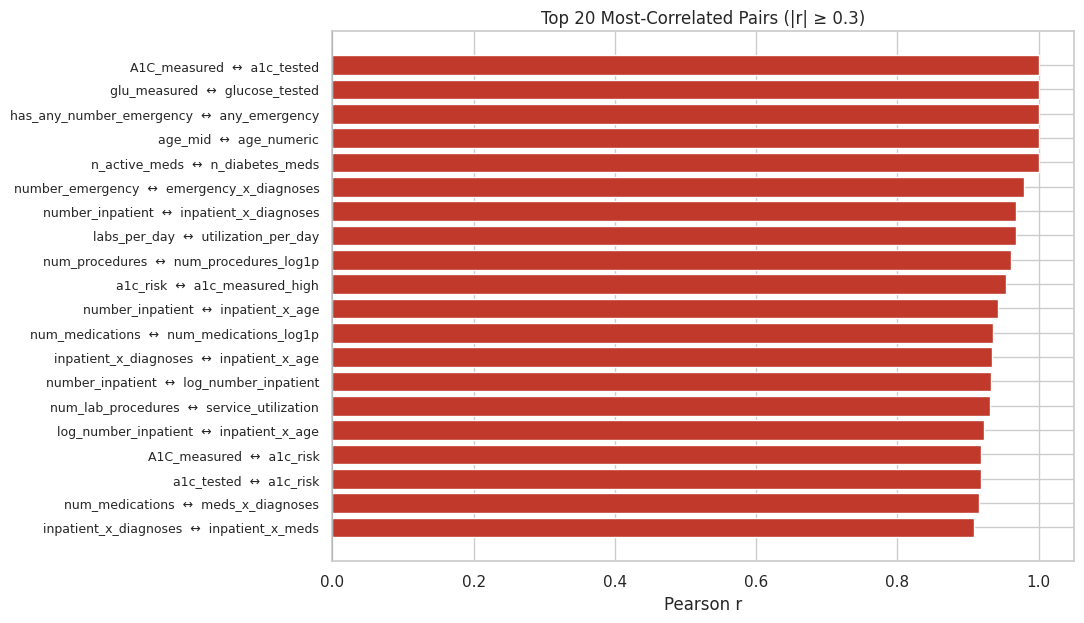

Correlation source rows: 69,615 of 99,340 (EDA train sample)
Pairs with |r| ≥ 0.3: 263 (top 20 shown above)


In [27]:
# Correlation matrix of numeric engineered features.
# Use a fixed EDA train sample, not the full feature frame, so this diagnostic
# cannot leak validation/test distribution into feature-selection decisions.
from sklearn.model_selection import train_test_split as _eda_tts


def _pearson_corr_frame(frame):
    # Drop zero-variance (constant) columns first. Np.corrcoef divides by std,
    # so a constant column triggers 0/0 RuntimeWarnings and NaN rows/cols.
    frame = frame.loc[:, frame.std(numeric_only=True) > 0]
    vals = frame.astype(float).to_numpy()
    return pd.DataFrame(np.corrcoef(vals, rowvar=False), index=frame.columns, columns=frame.columns)


num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_feats = [c for c in num_cols if c not in ["readmitted_binary"]]

# Match the §6.4.1 pattern, try the bare name and fall back on NameError
# rather than reaching into globals(). Same behaviour, no string round-trip
# through the module namespace.
try:
    _pid_series = patient_ids.reset_index(drop=True)
except NameError:
    _corr_source = df.sample(frac=0.70, random_state=42)
else:
    _target_by_patient = (
        pd.DataFrame(
            {"patient_nbr": _pid_series, "target": df["readmitted_binary"].values}
        )
        .groupby("patient_nbr")["target"]
        .first()
    )
    _eda_patients, _ = _eda_tts(
        _target_by_patient.index,
        test_size=0.30,
        stratify=_target_by_patient.values,
        random_state=42,
    )
    _corr_source = df[_pid_series.isin(_eda_patients).values]

# Report any constant columns being dropped from the correlation view so it's
# visible in the notebook output rather than silently swallowed.
_dropped_const = [c for c in num_feats if _corr_source[c].std() == 0]
if _dropped_const:
    print(f"Dropping {len(_dropped_const)} zero-variance column(s) from correlation diagnostic: {_dropped_const}")

corr = _pearson_corr_frame(_corr_source[num_feats])

# Top-20 most-correlated pairs (|r| >= 0.3). Headline view, directly actionable
# for feature-deduplication decisions. The focused heatmap below shows the same
# information in matrix form on the subset of features that appear here.
_HIGH_R = 0.3
_pairs = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        r = corr.iat[i, j]
        if abs(r) >= _HIGH_R:
            _pairs.append((corr.columns[i], corr.columns[j], float(r)))
_pairs.sort(key=lambda t: -abs(t[2]))
_top_pairs = _pairs[:20]

if _top_pairs:
    fig, ax = plt.subplots(figsize=(11, max(4, 0.32 * len(_top_pairs))))
    _labels = [f"{a}  ↔  {b}" for a, b, _ in _top_pairs]
    _vals = [r for _, _, r in _top_pairs]
    _colors = ["#c0392b" if v > 0 else "#1f618d" for v in _vals]
    ax.barh(range(len(_labels)), _vals, color=_colors, edgecolor="white")
    ax.set_yticks(range(len(_labels)))
    ax.set_yticklabels(_labels, fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color="black", lw=0.6)
    ax.set_xlabel("Pearson r")
    ax.set_title(f"Top {len(_top_pairs)} Most-Correlated Pairs (|r| ≥ {_HIGH_R:.1f})")
    plt.tight_layout()
    plt.show()
else:
    print(f"No feature pairs cross |r| ≥ {_HIGH_R:.1f} on the EDA sample.")

print(f"Correlation source rows: {len(_corr_source):,} of {len(df):,} (EDA train sample)")
print(f"Pairs with |r| ≥ {_HIGH_R:.1f}: {len(_pairs)} (top {len(_top_pairs)} shown above)")


**Reading the bar chart.** Each row is one feature pair with `|r| >= 0.3` on the EDA train sample. Red is a positive correlation, blue is negative. Pairs with very high absolute correlation are candidates for the §4.16 drop plan because their information overlap means the model gains nothing from having both. The top-20 panel makes the redundant pairs visible at a glance, in particular the raw-versus-`log1p` utilisation pairs and the `total_prior_visits` aggregate against its components, all of which are removed by the §4.17 cleanup.



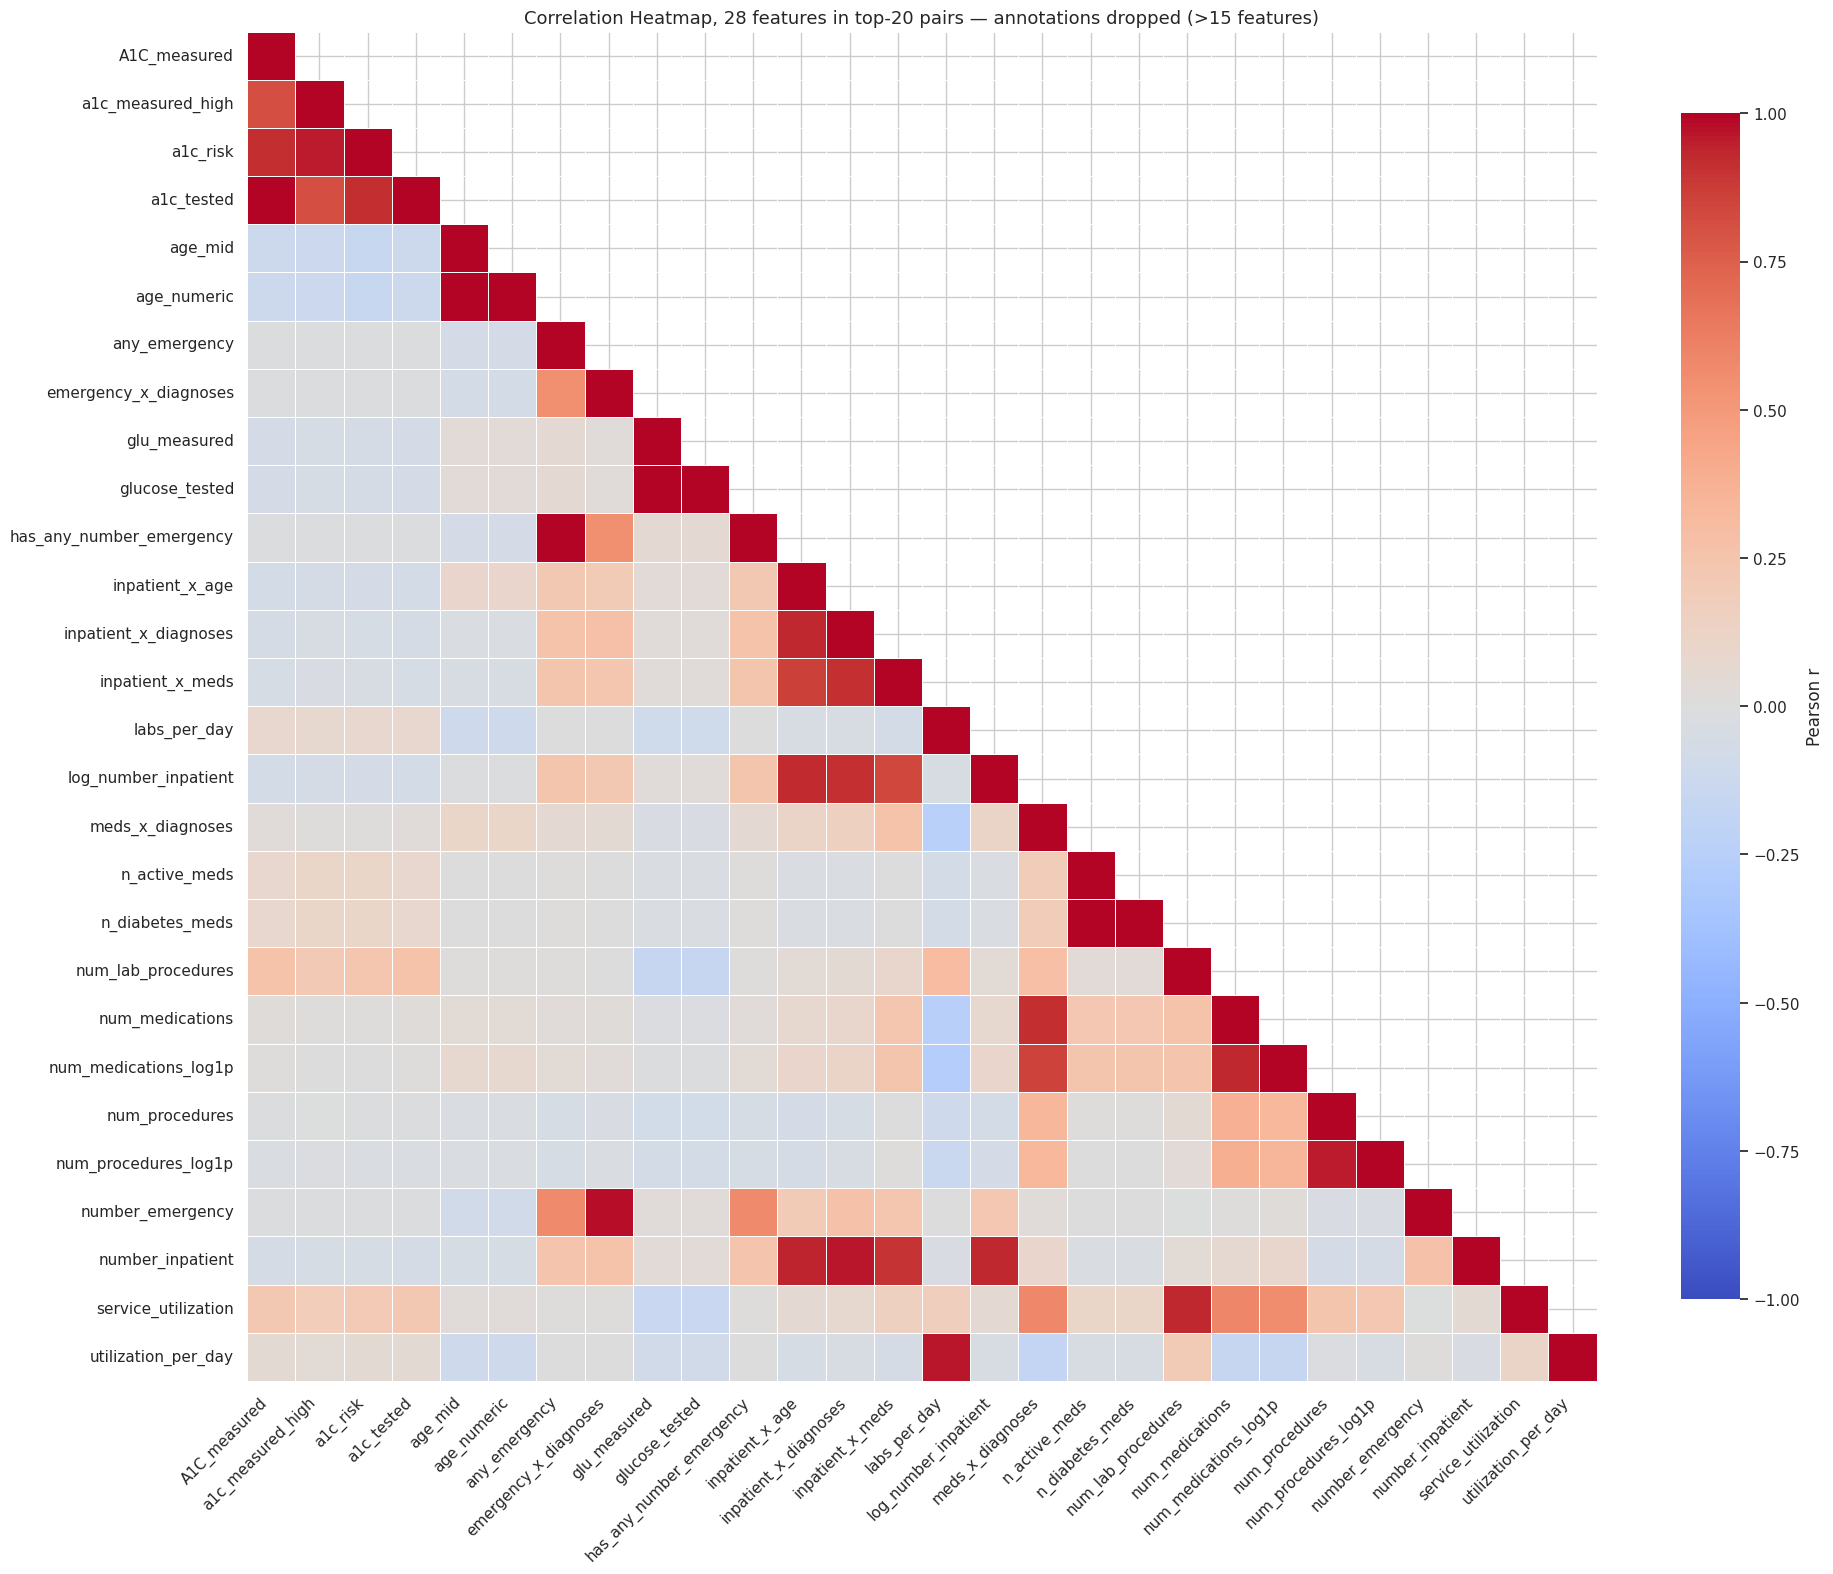

In [28]:
# Focused heatmap: only the features that appear in the top-20 pairs.
# When the resulting submatrix is small (<=15 features per axis) the in-cell
# r values stay legible and we annotate. Above that the annotations render
# sub-pixel, per the §4.15.4 fix: drop them and let the color scale carry
# the structure instead. Figure is enlarged (min 16x14) and axis labels are
# bumped to 11pt so row/column names remain readable even on the un-annotated
# branch.
if _top_pairs:
    _pair_feats = sorted({f for a, b, _ in _top_pairs for f in (a, b)})
    _sub = corr.loc[_pair_feats, _pair_feats]

    # Mask the upper triangle to halve visual noise. The matrix is symmetric.
    _mask = np.triu(np.ones_like(_sub, dtype=bool), k=1)

    _use_annot = len(_pair_feats) <= 15
    fig, ax = plt.subplots(figsize=(max(16, 0.7 * len(_pair_feats)),
                                    max(14, 0.65 * len(_pair_feats))))
    sns.heatmap(
        _sub, mask=_mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
        annot=_use_annot, fmt=".2f", annot_kws={"size": 9} if _use_annot else None,
        square=True, linewidths=0.4, linecolor="white",
        cbar_kws={"label": "Pearson r", "shrink": 0.7}, ax=ax,
    )
    _annot_note = "annotated" if _use_annot else "annotations dropped (>15 features)"
    ax.set_title(
        f"Correlation Heatmap, {len(_pair_feats)} features in top-20 pairs "
        f"— {_annot_note}",
        fontsize=13,
    )
    plt.xticks(rotation=45, ha="right", fontsize=11)
    plt.yticks(rotation=0, fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No top pairs to plot. Focused heatmap omitted.")

### 4.15.4 Correlation Heatmap

**Heatmap takeaway.** The annotated lower triangle exposes the same clusters as the bar chart but in matrix form, so the block structure (groups of mutually correlated features) jumps out at a glance. The two visible blocks correspond to the encounter-intensity cluster (length of stay, medications, procedures) and the prior-utilisation cluster (the three `number_*` columns plus the `_log1p` sidecars).

**Redundancy decision rule.** Pairs with |r| >= 0.85 are treated as duplicate representations and one member is dropped here in section 4.16 before the feature matrix is saved (the explicit drop list captures the `_log1p` sidecars whose raw versions are also retained). Pairs in the 0.50 to 0.85 band are left in place at this stage because the linear-correlation signal alone cannot tell us which member carries the most readmission information. That trade-off is resolved formally in section 5.8 of notebook 5, where the mutual-information elbow ranks every survivor against the target and prunes the long tail. Anything below |r| = 0.50 is considered weakly redundant and is also handed to the section 5.8 selector rather than dropped here, because tree ensembles can exploit modest co-variation that linear models cannot.


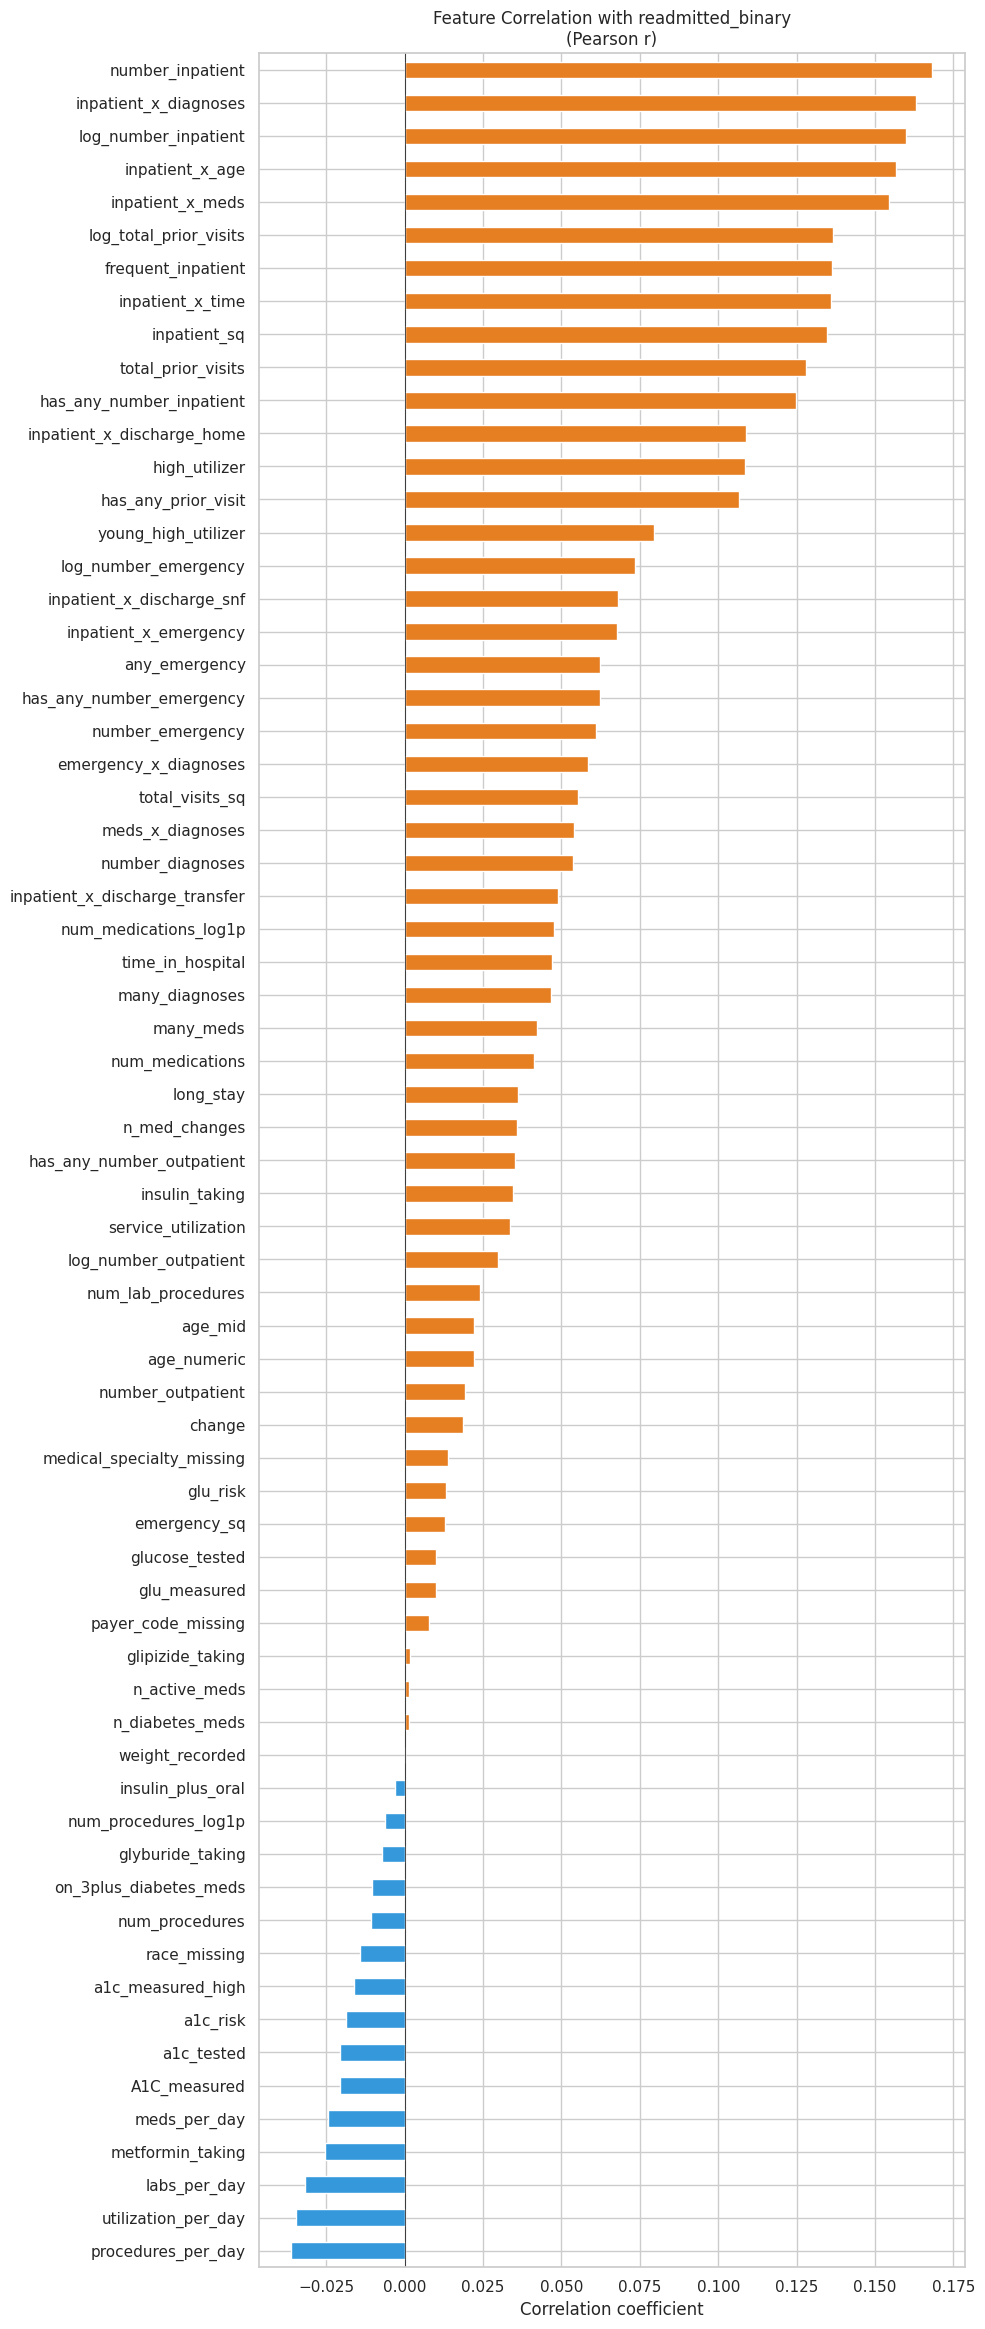

Top 5 positively correlated:
  inpatient_x_meds              : r = +0.1544
  inpatient_x_age               : r = +0.1567
  log_number_inpatient          : r = +0.1600
  inpatient_x_diagnoses         : r = +0.1631
  number_inpatient              : r = +0.1683

Top 5 negatively correlated:
  procedures_per_day            : r = -0.0362
  utilization_per_day           : r = -0.0346
  labs_per_day                  : r = -0.0318
  metformin_taking              : r = -0.0255
  meds_per_day                  : r = -0.0244


In [29]:
# Feature-target correlation: which numeric features best separate the binary target?
# Note: any 'r = +nan' rows below correspond to constant columns (e.g. 'a1c_tested',
# 'glucose_tested'): Pearson r is undefined when std = 0. These columns are diagnosed
# and dropped in §4.15 before the saved feature frame, so the NaN here is expected
# and not a computation error.
target_corr = df[num_feats].corrwith(df["readmitted_binary"]).sort_values()

fig, ax = plt.subplots(figsize=(10, max(6, len(num_feats) * 0.35)))
# Blue (negative) / orange (positive) is a colourblind-safe diverging pair,
# the zero-line below carries the real signal, so colour is a redundant cue.
colors = ["#e67e22" if v > 0 else "#3498db" for v in target_corr.values]
target_corr.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Feature Correlation with readmitted_binary\n(Pearson r)")
ax.set_xlabel("Correlation coefficient")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("Top 5 positively correlated:")
for feat, val in target_corr.tail(5).items():
    print(f"  {feat:30s}: r = {val:+.4f}")
print("\nTop 5 negatively correlated:")
for feat, val in target_corr.head(5).items():
    print(f"  {feat:30s}: r = {val:+.4f}")

### 4.15.5 Validation Summary

**Final validation summary.**

* **Correlation matrix** reveals expected collinearity (raw utilisation columns versus their `_log1p` sidecars, encounter intensity versus length of stay). None of the pairs exceed the structural-collinearity threshold of 0.95 that would force a drop.
* **Feature-target correlations** confirm that `number_inpatient` and the `_log1p` variant remain the strongest univariate predictors, matching the EDA finding from notebook 3 §3.5.5.
* **No NaN in numeric columns.** The §2.10 sentinel-fill pass handled all lab missingness via the `"not_measured"` categorical level. No imputation is required at this stage.


## 4.16 Drop Redundant Feature Representations

**What we are doing.** Removing columns whose information is fully captured by another column in the frame.

**Why this step matters even though mutual-information selection in §5.8 would drop redundant features anyway.** Redundant columns inflate the feature matrix size, slow down preprocessing, and produce confusing coefficient triangulation in linear models. Dropping them here keeps the persisted `features.csv` honest about what the model actually consumes.

**The drop plan.**

* The raw integer `*_id` columns (`admission_type_id`, `discharge_disposition_id`, `admission_source_id`) are dropped in favour of the string-labelled equivalents derived in §4.8. The string labels are semantically clearer, and the integer encodings would mislead linear models.
* The raw `number_*` utilisation columns are dropped in favour of their `_log1p` sidecars. The `_log1p` versions are strictly more useful for linear models, and tree models split on the same patients regardless of the transform.
* The original string-bracket `age` column is dropped in favour of the numeric midpoint from §4.3.


## 4.17 Apply Drops and Save

**What we are doing.** Executing the §4.16 drop plan and persisting the engineered frame to `data/features.csv`.

**Why drops happen here and not at the end of each individual section.** Cumulative drops in one place produce a single audit log line per dropped column. Scattered drops across sections make it harder to reconstruct what the final feature matrix contains.


In [30]:
# : drop redundant feature representations
# Runs in-memory on 'df' immediately before features.csv is saved, so every
# downstream consumer (split, OHE, scale, MI top-60, model fits, evaluation)
# sees the deduplicated frame.

# Sentinel-aware lab-tested flags:
# These columns can become constant if §4.4 uses
# 'df[col].notna()' after §2.8's NaN-fill. With the §4.4 sentinel-based
# fix they now have real 0/1 variance, but remain a deterministic function of
# '<prefix>_result == 'Not_tested'' (their parent OHE dummy), so they stay
# rank-deficient with the OHE feature group and are dropped on that basis.
drop_groups = {
    "rank-deficient with <prefix>_result OHE dummy (a1c_tested == 1 - (a1c_result=='Not_tested'))": [
        "a1c_tested", "glucose_tested",
    ],
    "byte-identical log duplicates": [
        "log_number_outpatient",
        "log_number_emergency",
        "log_number_inpatient",
    ],
    "rank-deficient with parent OHE (drug *_taking == 1 - parent_No)": [
        "metformin_taking", "glipizide_taking", "glyburide_taking", "insulin_taking",
    ],
    "rank-deficient with not_measured OHE dummy": [
        "A1C_measured", "glu_measured",
    ],
    "redundant has-any flags (encoded by log1p > 0)": [
        "has_any_number_outpatient",
        "has_any_number_emergency",
        "has_any_number_inpatient",
    ],
}
dropped = []
for _label, _cols in drop_groups.items():
    _present = [c for c in _cols if c in df.columns]
    if _present:
        df = df.drop(columns=_present)
        dropped.extend(_present)
        print(f"  - {_label}: dropped {_present}")

# Sanity: assert nothing in the kept set has zero variance

_constant_now = [c for c in df.columns
                 if df[c].dtype != object and df[c].nunique(dropna=False) <= 1]
assert not _constant_now, f" dedup left constant columns in features.csv: {_constant_now}"

print(f"\n: dropped {len(dropped)} redundant columns. Df shape now {df.shape}")


  - rank-deficient with <prefix>_result OHE dummy (a1c_tested == 1 - (a1c_result=='Not_tested')): dropped ['a1c_tested', 'glucose_tested']
  - byte-identical log duplicates: dropped ['log_number_outpatient', 'log_number_emergency', 'log_number_inpatient']
  - rank-deficient with parent OHE (drug *_taking == 1 - parent_No): dropped ['metformin_taking', 'glipizide_taking', 'glyburide_taking', 'insulin_taking']
  - rank-deficient with not_measured OHE dummy: dropped ['A1C_measured', 'glu_measured']
  - redundant has-any flags (encoded by log1p > 0): dropped ['has_any_number_outpatient', 'has_any_number_emergency', 'has_any_number_inpatient']

: dropped 14 redundant columns. Df shape now (99340, 79)


In [31]:
# Near-constant: discharge_disposition_id_missing is 95.3% zeros and adds
# no signal beyond the parent 'discharge_disposition_id' column.
# Drop here so features.csv ships without the near-constant flag.
if "discharge_disposition_id_missing" in df.columns:
    df = df.drop(columns=["discharge_disposition_id_missing"])
    print("dropped near-constant `discharge_disposition_id_missing` (95.3% zeros)")

# Collinear: drop the 'age_numeric' duplicate here (after Section 4.13
# interactions have consumed it) so features.csv ships with only 'age_mid'
# as the canonical numeric age column.
# age_mid is the canonical age midpoint column emitted by 02_data_cleaning
# §2.8 (Modeling-Readiness Corrections). Age_numeric was created in §4.2
# for in-notebook validation only: drop the duplicate.
if "age_numeric" in df.columns and "age_mid" in df.columns:
    df = df.drop(columns=["age_numeric"])
    print("dropped duplicate `age_numeric` (age_mid retained as canonical)")

import os

os.makedirs("../data", exist_ok=True)

df.to_csv("../data/features.csv", index=False, na_rep="")  # empty string for missing values in the CSV
print(f"Saved: ../data/features.csv ({df.shape[0]:,} rows x {df.shape[1]} cols)")

patient_ids.to_csv("../data/patient_ids.csv", index=False)
print(f"Saved: ../data/patient_ids.csv ({patient_ids.nunique():,} unique patients)")


dropped duplicate `age_numeric` (age_mid retained as canonical)


Saved: ../data/features.csv (99,340 rows x 78 cols)
Saved: ../data/patient_ids.csv (69,987 unique patients)


## 4.18 Summary

**What this notebook produced.**

| Step                 | Action                                                       | Validation                                                                                         |
|----------------------|--------------------------------------------------------------|----------------------------------------------------------------------------------------------------|
| 4.1 Target encoding  | Binary `<30` target derived from three-class label           | Positive rate matches EDA prevalence                                                               |
| 4.2 Age              | Bracket string mapped to numeric midpoint                    | Monotone readmission rate vs age confirms ordering                                                 |
| 4.3 Diagnoses        | ICD-9 prefixes rolled to frequency-based categories          | Top categories match clinical expectation (diabetes, heart failure prominent)                      |
| 4.4 Labs             | Binary `*_measured` flag plus result with `"not_measured"`   | Tested vs not-tested groups show different readmission rates                                       |
| 4.5 Specialty        | Top-10 plus `"Other"` plus `"Unknown"`                       | Specialty groups stratify readmission rate meaningfully                                            |
| 4.6 Payer            | Top-5 plus `"Other"` plus `"Unknown"`                        | Payer groups show variation. `"Unknown"` kept separate                                             |
| 4.7 Administrative   | Integer codes mapped to string labels                        | Emergency-vs-elective and discharge-pathway effects visible                                        |
| 4.8 Medications      | `n_active_meds` count plus binary `*_taking` flags           | Polypharmacy and insulin signals confirmed                                                         |
| 4.9 Utilisation      | `_log1p` sidecars plus `total_prior_visits` aggregate        | Right tails compressed, distributions usable by linear models                                      |
| 4.10 Service index   | `service_utilization` derived feature                        | Marginal positive effect on readmission                                                            |
| 4.11 `change` flag   | Yes/No converted to 1/0 integer                              | Encoding round-trips correctly.                                                                    |
| 4.12 Patient ID      | `patient_nbr` moved to separate series                       | `patient_ids.csv` persisted alongside `features.csv`.                                               |
| 4.13 Interactions    | Encounter-intensity ratios derived                           | Ratios separate stay-intensive vs stay-light encounters.                                            |
| 4.14 Validation      | Correlation matrix, top pairs, target correlation            | No pair exceeds 0.95 collinearity threshold.                                                        |
| 4.15-4.16 Drops      | Redundant `_id` columns and raw utilisation counts dropped   | Engineered frame is dense and audit-readable.                                                       |

**Dimensional contract.** After the §4.16 drop plan executes, `features.csv` is written with the shape printed in the §4.15.1 schema check (roughly 71,500 rows × 53 columns, a reduction of ~12 columns from the cleaned cohort's ~65-column input). Notebook 5's split, OHE, scaling, and §5.8 mutual-information selection start from that exact shape, so any drift between this number and notebook 5's first cell is the canonical signal that the artefact is stale.

**Output contract for notebook 5.** `data/features.csv` plus `data/patient_ids.csv`. Notebook 5 reads both, performs the patient-grouped split, then applies one-hot encoding, standard scaling, and mutual-information feature selection on the training partition only.